In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import warnings 
warnings.filterwarnings("ignore")

In [6]:
from DFTStructureGenerator.draw import plot_scatter_fit, plot_distribution, plot_panel
from DFTStructureGenerator.Build_DataBase import build_databases
from DFTStructureGenerator.Tool import get_bond_angle
from tqdm import tqdm
from rdkit import Chem
from DFTStructureGenerator.logfile_process import Logfile
from DFTStructureGenerator import B_N_Cl
import os
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from ase import Atoms
from ase.db import connect

In [ ]:
duplicate_N_id = [9, 43, 285, 310, 314, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 372, 375, 376]



Borane_df = pd.read_csv(r'Data\csvs\reactants_B.csv')
nu_df = pd.read_csv(r'Data\csvs\reactants_N.csv').dropna(subset=['G_energy_r'])
Cl_df = pd.read_csv(r'Data\csvs\reactants_Cl.csv')
Borane_nu_df = pd.read_csv(r'Data\csvs\reactants_B_N.csv')
reaction_df = pd.read_csv(r'E:\work\B_Cl_Nu\Sum\Borane_all.csv')


# raise NameError
combined_data = {}
temp_combined_data = {}

# ======================== B monomer (open shell) ========================
for row_id, row in Borane_df.iterrows():
    idx, conf_idxs_r, G = row['Index'], int(row['conf_idxs_r']), row['G_energy_r']
    mol = Chem.MolFromMolFile(rf'E:\work\B_Cl_Nu\Data\Mols\B_{idx:05}_r.mol', removeHs=False)
    [atom.SetAtomMapNum(atom.GetIdx()) for atom in mol.GetAtoms()]
    smiles = Chem.MolToSmiles(mol)
    log_file = rf'E:\work\B_Cl_Nu\Data\GS_OPT\B_single\B_{idx:05}_r_{conf_idxs_r:04}.log'
    log = Logfile(log_file)
    atoms = Atoms(symbols=log.symbol_list, positions=log.running_positions[-1])
    # Descriptor: SPE log
    spe_log_file = log_file.replace("GS_OPT", "GS_SPE")
    spe_log = Logfile(spe_log_file)
    dipole_moment = spe_log.get_dipole()
    _, spin_densities = spe_log.read_charge_spin_density()
    orbital_energies = spe_log.read_orbit_eng(HOMO_index=[-1], LUMO_index=[0])[:2]  # Open the shell and take the first 2
    combined_data[f'B_{idx:05}'] = {
        "smiles": smiles, "atoms": atoms, "gibbs_hartree": G,
        "dipole_moment": dipole_moment,
        "spin_densities": spin_densities,
        "homo_energy_kcal": orbital_energies[0],
        "lumo_energy_kcal": orbital_energies[1],
    }

# ======================== LB / Nu monomer (closed shell) ========================
for row_id, row in nu_df.iterrows():
    idx, conf_idxs_r, G = row['Index'], int(row['conf_idxs_r']), row['G_energy_r']
    mol = Chem.MolFromMolFile(rf'E:\work\B_Cl_Nu\Data\Mols\N_{idx:05}_r.mol', removeHs=False)
    [atom.SetAtomMapNum(atom.GetIdx()) for atom in mol.GetAtoms()]
    smiles = Chem.MolToSmiles(mol)
    log_file = rf'E:\work\B_Cl_Nu\Data\GS_OPT\N_single\N_{idx:05}_r_{conf_idxs_r:04}.log'
    log = Logfile(log_file)
    atoms = Atoms(symbols=log.symbol_list, positions=log.running_positions[-1])
    # Descriptor: SPE log
    spe_log_file = log_file.replace("GS_OPT", "GS_SPE")
    spe_log = Logfile(spe_log_file)
    dipole_moment = spe_log.get_dipole()
    orbital_energies = spe_log.read_orbit_eng(HOMO_index=[-1], LUMO_index=[0])  # Closed shell layer returns 2
    combined_data[f'LB_{idx:05}'] = {
        "smiles": smiles, "atoms": atoms, "gibbs_hartree": G,
        "dipole_moment": dipole_moment,
        "homo_energy_kcal": orbital_energies[0],
        "lumo_energy_kcal": orbital_energies[1],
    }

# ======================== Cl substrate (r closed shell) / C radical (p open shell) ========================
for row_id, row in Cl_df.iterrows():
    idx, conf_idxs_r, conf_idxs_p, G_r, G_p = row['Index'], int(row['conf_idxs_r']), int(row['conf_idxs_p']), row['G_energy_r'], row['G_energy_p']
    for conf_id, state, G in [[conf_idxs_r, 'r', G_r], [conf_idxs_p, 'p', G_p]]:
        mol = Chem.MolFromMolFile(rf'E:\work\B_Cl_Nu\Data\Mols\Cl_{idx:05}_{state}.mol', removeHs=False)
        [atom.SetAtomMapNum(atom.GetIdx()) for atom in mol.GetAtoms()]
        smiles = Chem.MolToSmiles(mol)
        log_file = rf'E:\work\B_Cl_Nu\Data\GS_OPT\Cl_{state}\Cl_{idx:05}_{state}_{conf_id:04}.log'
        log = Logfile(log_file)
        atoms = Atoms(symbols=log.symbol_list, positions=log.running_positions[-1])
        # Descriptor: SPE log
        spe_log_file = log_file.replace("GS_OPT", "GS_SPE")
        spe_log = Logfile(spe_log_file)
        chg_file = spe_log_file.replace(".log", ".chg").replace("GS_SPE", "GS_SPE_wfn")
        hirshfeld_charges = B_N_Cl.FormatConverter.read_chg_file(chg_file)['charge'].to_list()
        dipole_moment = spe_log.get_dipole()
        entry = {
            "smiles": smiles, "atoms": atoms, "gibbs_hartree": G,
            "hirshfeld_charges": hirshfeld_charges,
            "dipole_moment": dipole_moment,
        }
        if state == 'p':
            # c_radical: open shell → spin density + orbital [:2]
            _, spin_densities = spe_log.read_charge_spin_density()
            orbital_energies = spe_log.read_orbit_eng(HOMO_index=[-1], LUMO_index=[0])[:2]
            entry["spin_densities"] = spin_densities
        else:
            # Cl_r: closed shell
            orbital_energies = spe_log.read_orbit_eng(HOMO_index=[-1], LUMO_index=[0])
        entry["homo_energy_kcal"] = orbital_energies[0]
        entry["lumo_energy_kcal"] = orbital_energies[1]
        combined_data[f'Cl_{idx:05}_{state}'] = entry

# ======================== TS transition state ========================
BN_smiles = {}

for row_id, row in tqdm(reaction_df.iterrows()):
    B_idx, N_idx, Cl_idx, conf_id, G, N_atom, AAM = row['B_Index'], row['N_Index'], row['Cl_Index'], row['conf_idxs_ts'], row['TS_G'], int(row['N_Atomid']), row['AAM']
    log_file = rf'E:\work\B_Cl_Nu\Sum\TS_needIRC\B_{B_idx:05}_Nu_{N_idx:05}_Cl_{Cl_idx:05}.log'
    if not os.path.exists(log_file):
        log_file = rf'E:\work\B_Cl_Nu\Sum\TS_needIRC\B_{B_idx:05}_Nu_{N_idx:05}_Cl_{Cl_idx:05}_{conf_id:04}.log'
    
    irc_forward = log_file.replace("TS_needIRC", "IRC_Full").replace(".log", "forward.log")
    irc_reverse = log_file.replace("TS_needIRC", "IRC_Full").replace(".log", "reverse.log")
    log = Logfile(log_file)
    first_unreal_freq = log.first_unreal_freq
    first_unreal_freq_matrix = np.array(log.unreal_freq_matrix)
    atoms = Atoms(symbols=log.symbol_list, positions=log.running_positions[-1])

    # IRC endpoint structure
    irc_fwd_positions = None
    irc_rev_positions = None
    if os.path.exists(irc_forward):
        irc_fwd_log = Logfile(irc_forward)
        irc_fwd_positions = irc_fwd_log.running_positions[-1].tolist()
    if os.path.exists(irc_reverse):
        irc_rev_log = Logfile(irc_reverse)
        irc_rev_positions = irc_rev_log.running_positions[-1].tolist()

    temp_combined_data[f'B_{B_idx:05}_LB_{N_idx:05}_Cl_{Cl_idx:05}'] = {
        "smiles": AAM, "atoms": atoms, "gibbs_hartree": G,
        "imaginary_frequency_cm_1": float(first_unreal_freq),
        "imaginary_freq_displacement": first_unreal_freq_matrix.tolist(),
        "irc_forward_positions": irc_fwd_positions,
        "irc_reverse_positions": irc_rev_positions,
    }
    BN_name = f'{B_idx:05}_{N_idx:05}'
    if N_idx in duplicate_N_id:
        BN_name = f'{B_idx:05}_{N_idx:05}_{N_atom}'

    BN_smiles[f'{BN_name}_r'] = row['AAM'].split(">>")[0].split('.')[0]
    BN_smiles[f'{BN_name}_p'] = row['AAM'].split(">>")[1].split('.')[0]


# ======================== B-LB complex (r open shell / p closed shell) ========================
for row_id, row in tqdm(Borane_nu_df.iterrows()):
    B_idx, N_idx, conf_idxs_r, conf_idxs_p, G_r, G_p, N_atom, B_atom = row['B_Index'], row['N_Index'], int(row['conf_idxs_r']), int(row['conf_idxs_p']), row['G_energy_r'], row['G_energy_p'], int(row['N_Atomid']), int(row['B_Atomid'])
    B_smiles = row['B_smiles'] 
    N_smiles = row['N_smiles']
    react_mol, product_mol = B_N_Cl.generate_ts_mol(B_smiles, N_smiles, B_atom, N_atom)
    react_smiles, product_smiles = Chem.MolToSmiles(react_mol), Chem.MolToSmiles(product_mol)
    for conf_id, state, G, smiles in [[conf_idxs_r, 'r', G_r, react_smiles], [conf_idxs_p, 'p', G_p, product_smiles]]:
        BN_name = f'{B_idx:05}_{N_idx:05}'
        if N_idx in duplicate_N_id:
            BN_name = f'{B_idx:05}_{N_idx:05}_{N_atom}'
        # if f'{BN_name}_{state}' not in BN_smiles.keys():
        #     continue
        # smiles = BN_smiles[f'{BN_name}_{state}']
        log_file = rf'E:\work\B_Cl_Nu\Data\GS_OPT\B_N_{state}\B_{B_idx:05}_Nu_{N_idx:05}_{state}_{conf_id:04}.log'
        if N_idx in duplicate_N_id:
            log_file = rf'E:\work\B_Cl_Nu\Data\GS_OPT\B_N_{state}_d\B_{B_idx:05}_Nu_{N_idx:05}_Naid_{N_atom:05}_{state}_{conf_id:04}.log'
        if not os.path.exists(log_file):
            print(BN_name, 'Not Found')
        log = Logfile(log_file)
        atoms = Atoms(symbols=log.symbol_list, positions=log.running_positions[-1])
        # Descriptor: SPE log
        spe_log_file = log_file.replace("GS_OPT", "GS_SPE")
        spe_log = Logfile(spe_log_file)
        chg_file = spe_log_file.replace(".log", ".chg").replace("GS_SPE", "GS_SPE_wfn")
        hirshfeld_charges = B_N_Cl.FormatConverter.read_chg_file(chg_file)['charge'].to_list()
        dipole_moment = spe_log.get_dipole()
        entry = {
            "smiles": smiles, "atoms": atoms, "gibbs_hartree": G,
            "hirshfeld_charges": hirshfeld_charges,
            "dipole_moment": dipole_moment,
        }
        if state == 'r':
            # complex_r: open shell → spin density + orbital take[:2]
            _, spin_densities = spe_log.read_charge_spin_density()
            orbital_energies = spe_log.read_orbit_eng(HOMO_index=[-1], LUMO_index=[0])[:2]
            entry["spin_densities"] = spin_densities
        else:
            # complex_p: closed shell
            orbital_energies = spe_log.read_orbit_eng(HOMO_index=[-1], LUMO_index=[0])
        entry["homo_energy_kcal"] = orbital_energies[0]
        entry["lumo_energy_kcal"] = orbital_energies[1]
        combined_data[f'B_{B_idx:05}_LB_{N_idx:05}_{state}'] = entry

combined_data = combined_data | temp_combined_data

In [ ]:
build_databases(combined_data, rewrite=True)

In [4]:
db = connect("boron_ccl2.db")
reaction_df = pd.read_csv("data/TS/Borane_all.csv")

# Figure 1

[0, 24, 30, 1]
B_Radical_TypeColors


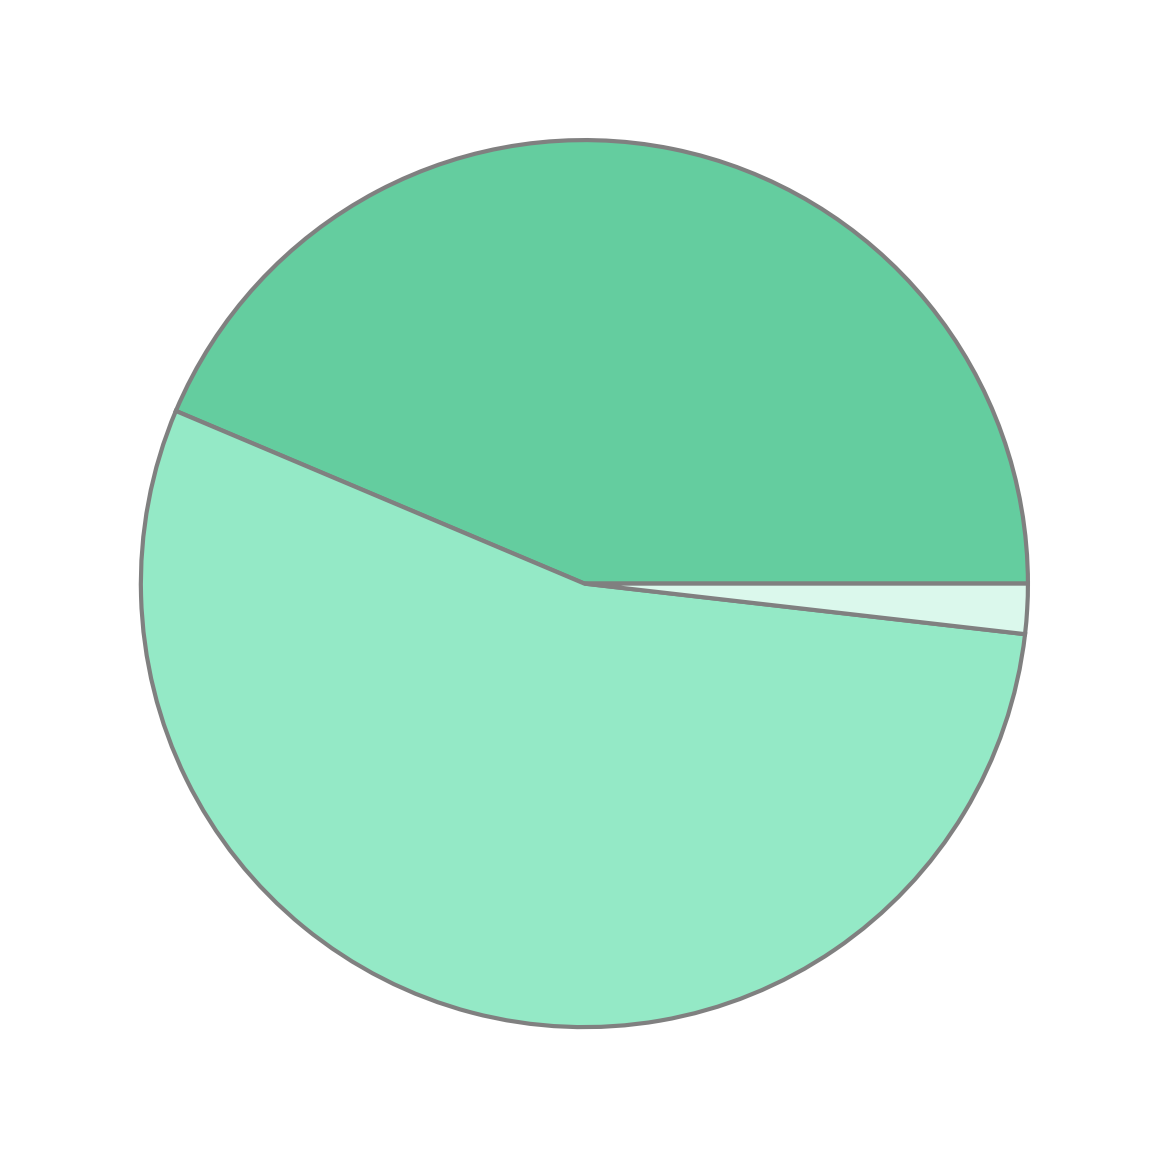

In [333]:
# Make a pie chart of all types of B
all_B_type = [0,0,0,0]
for row in db.select(category="B"):
    B_atom = [atom for atom in Chem.MolFromSmiles(row.smiles).GetAtoms() if atom.GetSymbol() == "B"][0]
    H_neighbors = B_atom.GetTotalNumHs()
    all_B_type[H_neighbors] += 1
print(all_B_type)
colors = ['#ff9999', "#64cd9f", "#94e9c6", "#dbf8ec"]
plt.figure(dpi=300)
plt.pie(all_B_type, 
        colors=colors, 
        wedgeprops={'edgecolor': 'gray', 'linewidth': 1})
print("B_Radical_TypeColors")
plt.savefig("Figure/Figure1_B_Radical_TypeColors.png", dpi=300)

[222, 75, 89, 0] 386
B_Radical_TypeColors


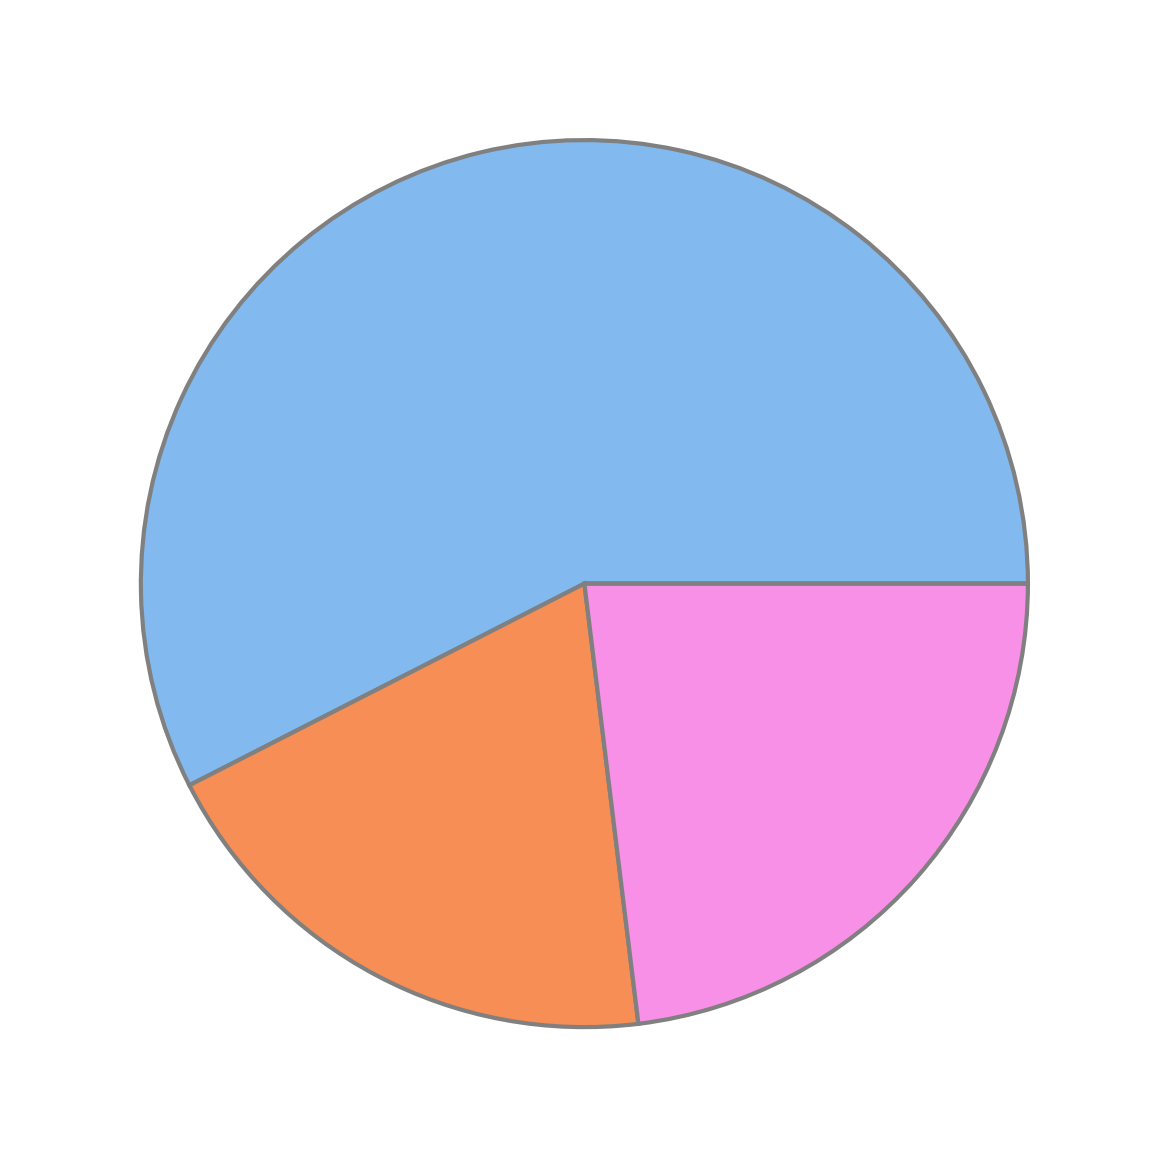

In [ ]:
# Make a pie chart of all types of LB
Anime_LB = np.arange(0,69)
Phosphine_LB = np.arange(69, 144)
NHC_LB = np.arange(144, 234)
Ar_LB = np.arange(234, 388)
all_nu_types = [0] * 4
for row in db.select(category="LB"):
    for id, nu in enumerate([np.append(Anime_LB, Ar_LB), Phosphine_LB, NHC_LB, ]):
        if int(row.key.split("_")[1]) in nu:
            all_nu_types[id] += 1
print(all_nu_types, np.sum(all_nu_types))
colors = [ "#82baef", "#f68e56", "#f990e7"]
plt.figure(dpi=300)
plt.pie(all_nu_types, colors=colors, 
        wedgeprops={'edgecolor': 'gray', 'linewidth': 1})
print("B_Radical_TypeColors")
plt.savefig("Figure/Figure1_LB_TypeColors.png", dpi=300)

In [318]:
num_Cl_substit

[102, 40, 36, 1]

[1, 36, 40, 102, 0, 0] [1, 36, 40, 102, 0, 0] 179


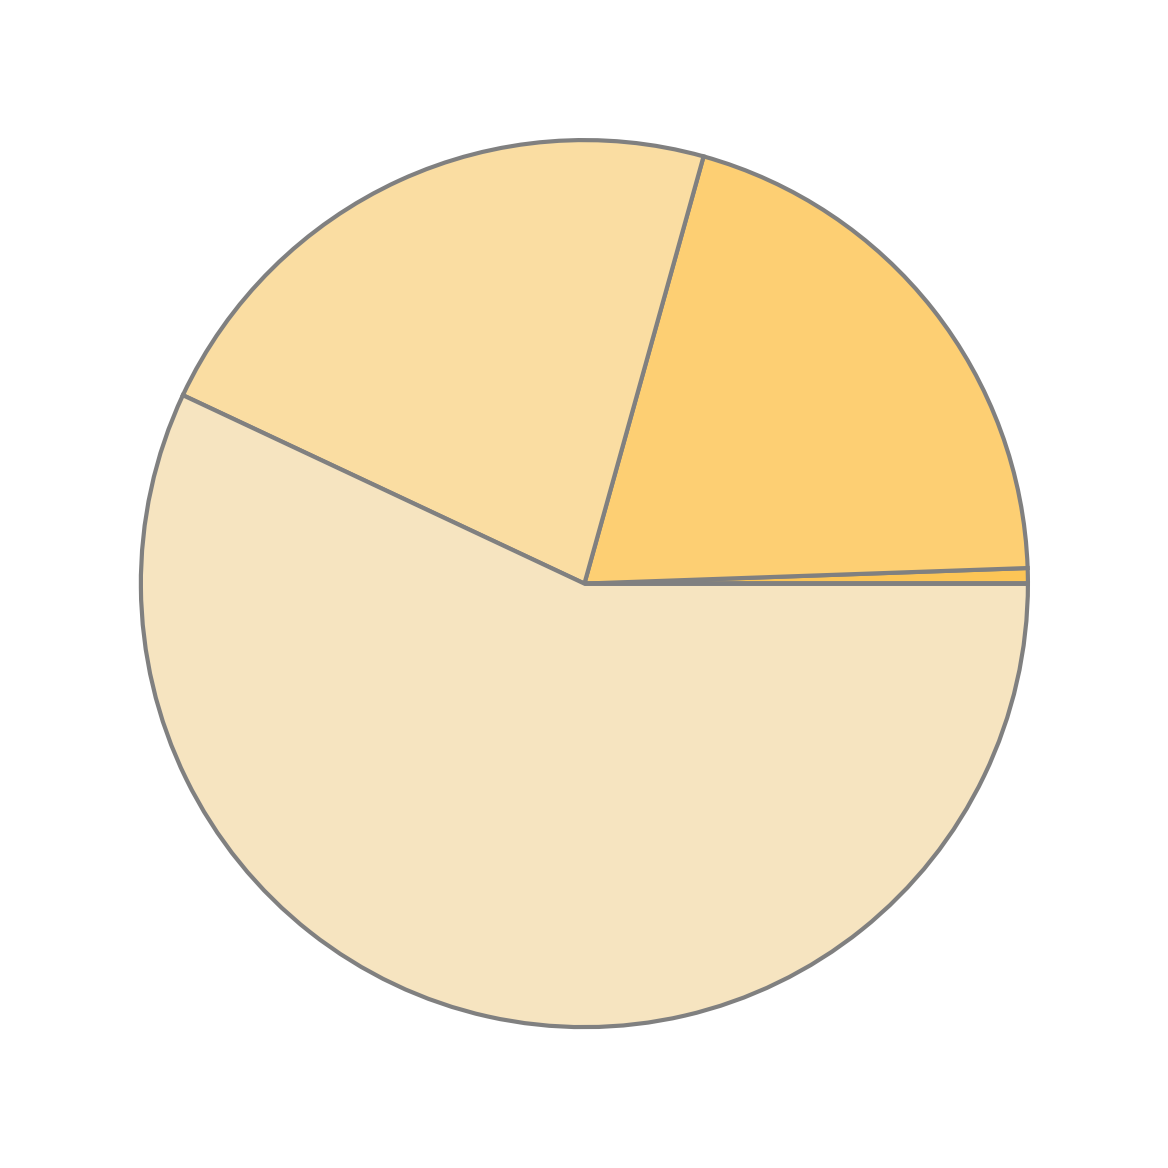

In [352]:
# Make a pie chart of all types of Cl
num_Cl_substit = [0,0,0,0,0,0]
for row in db.select(category="Cl"):
    Cl_mol = Chem.AddHs(Chem.MolFromSmiles(row.smiles))
    if Cl_mol.HasSubstructMatch(Chem.MolFromSmarts("Cl*(Cl)(Cl)Cl")):
        num_Cl_substit[0] += 1
    elif Cl_mol.HasSubstructMatch(Chem.MolFromSmarts("Cl*(Cl)Cl")):
        num_Cl_substit[1] += 1
    elif Cl_mol.HasSubstructMatch(Chem.MolFromSmarts("Cl*Cl")):
        num_Cl_substit[2] += 1
    else:
        num_Cl_substit[3] += 1
colors = ["#fcc556", "#fdcf73", "#fadda2", "#f6e4c0", "#f6efe0"]
print(num_Cl_substit, num_Cl_substit, np.sum(num_Cl_substit))
plt.figure(dpi=300)
# plt.pie(num_Cl_substit, colors=colors, 
#         wedgeprops={'edgecolor': 'gray', 'linewidth': 1})
# plt.savefig("Figure/Figure1_Cl_ClAtomColors.png", dpi=300)
# plt.show()
plt.pie(num_Cl_substit, colors=colors, 
        wedgeprops={'edgecolor': 'gray', 'linewidth': 1})
plt.savefig("Figure/Figure1_Cl_Csp23Colors.png", dpi=300)
plt.show()


## LB details

[68, 112, 40, 2]
B_Radical_TypeColors


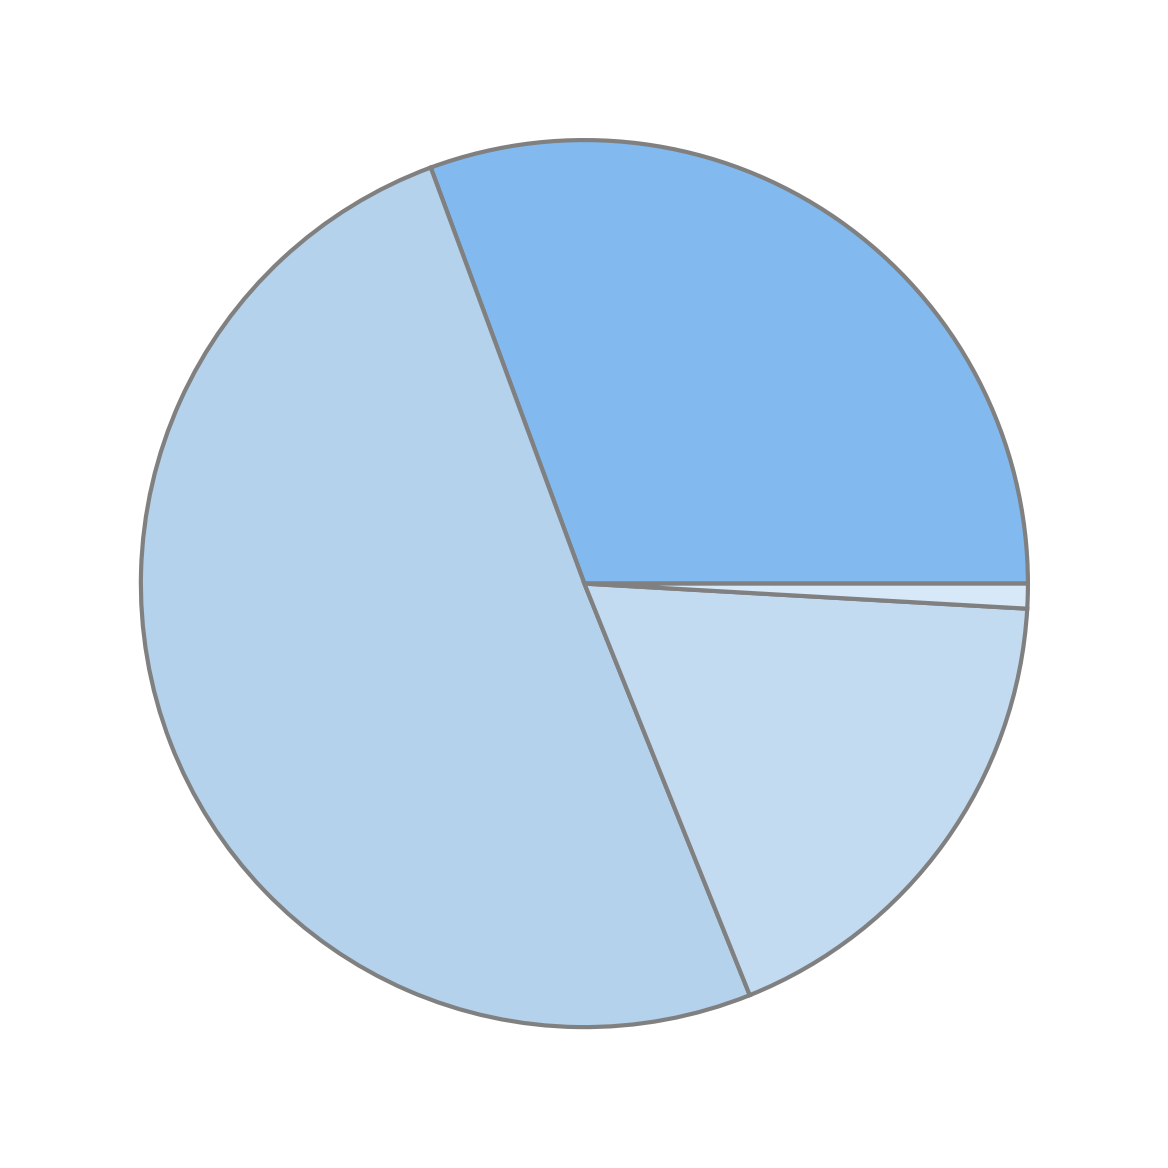

In [ ]:
# Making a pie chart of Phosphine's LB
all_lb_type = [[], [], [], []]
colors = ["#82baef", "#b4d2ec", "#c2dbf1", "#d7e8f8"]
for row in db.select(category="LB"):
    if int(row.key.split("_")[1]) in np.append(Anime_LB, Ar_LB):
        if Chem.MolFromSmiles(row.smiles).HasSubstructMatch(Chem.MolFromSmarts("n1*****1")):
            all_lb_type[1].append(row.smiles)
        elif Chem.MolFromSmiles(row.smiles).HasSubstructMatch(Chem.MolFromSmarts("n1****1")):
            all_lb_type[2].append(row.smiles)
        elif int(row.key.split("_")[1]) in Anime_LB:
            all_lb_type[0].append(row.smiles)
        else:
            all_lb_type[3].append(row.smiles)
print([len(each) for each in all_lb_type])
plt.figure(dpi=300)
plt.pie([len(each) for each in all_lb_type], colors=colors, wedgeprops={'edgecolor': 'gray', 'linewidth': 1})
print("B_Radical_TypeColors")
plt.savefig("Figure/Figure1_LB_TypeColors.png", dpi=300)

[33, 42, 0, 0]
B_Radical_TypeColors


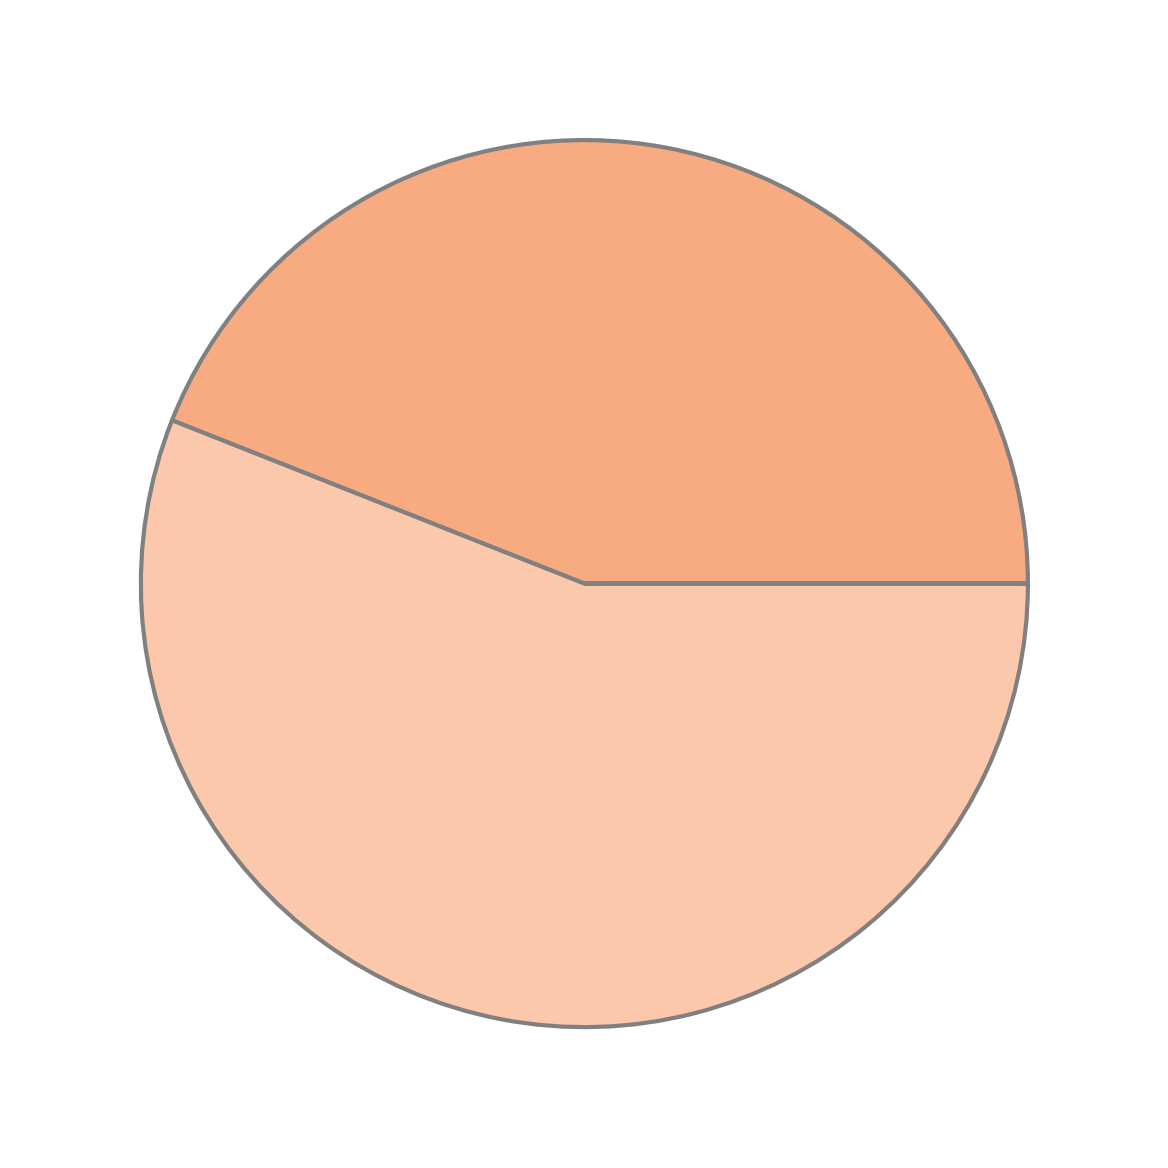

In [ ]:
# Making a pie chart of Phosphine's LB
all_P_type = [[], [], [], []]
for row in db.select(category="LB"):
    if int(row.key.split("_")[1]) in Phosphine_LB:
        if Chem.MolFromSmiles(row.smiles).HasSubstructMatch(Chem.MolFromSmarts("[P,p]a")):
            all_P_type[0].append(row.smiles)
        # elif Chem.MolFromSmiles(row.smiles).HasSubstructMatch(Chem.MolFromSmarts("[P,p](a)a")):
        #     all_P_type[1].append(row.smiles)
        # elif Chem.MolFromSmiles(row.smiles).HasSubstructMatch(Chem.MolFromSmarts("[P,p]a")):
        #     all_P_type[2].append(row.smiles)
        else:
            all_P_type[1].append(row.smiles)
colors = ["#f8ab81", "#fcc8ac", "#fdd8c4", "#fce4d6"]
print([len(each) for each in all_P_type])
plt.figure(dpi=300)
plt.pie([len(each) for each in all_P_type], colors=colors, wedgeprops={'edgecolor': 'gray', 'linewidth': 1})
print("B_Radical_TypeColors")
plt.savefig("Figure/Figure1_LB_P_TypeColors.png", dpi=300)

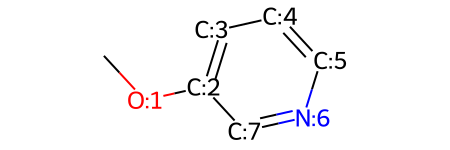

In [19]:
kekulize_mol

[18, 28, 9, 10, 24]
B_Radical_TypeColors


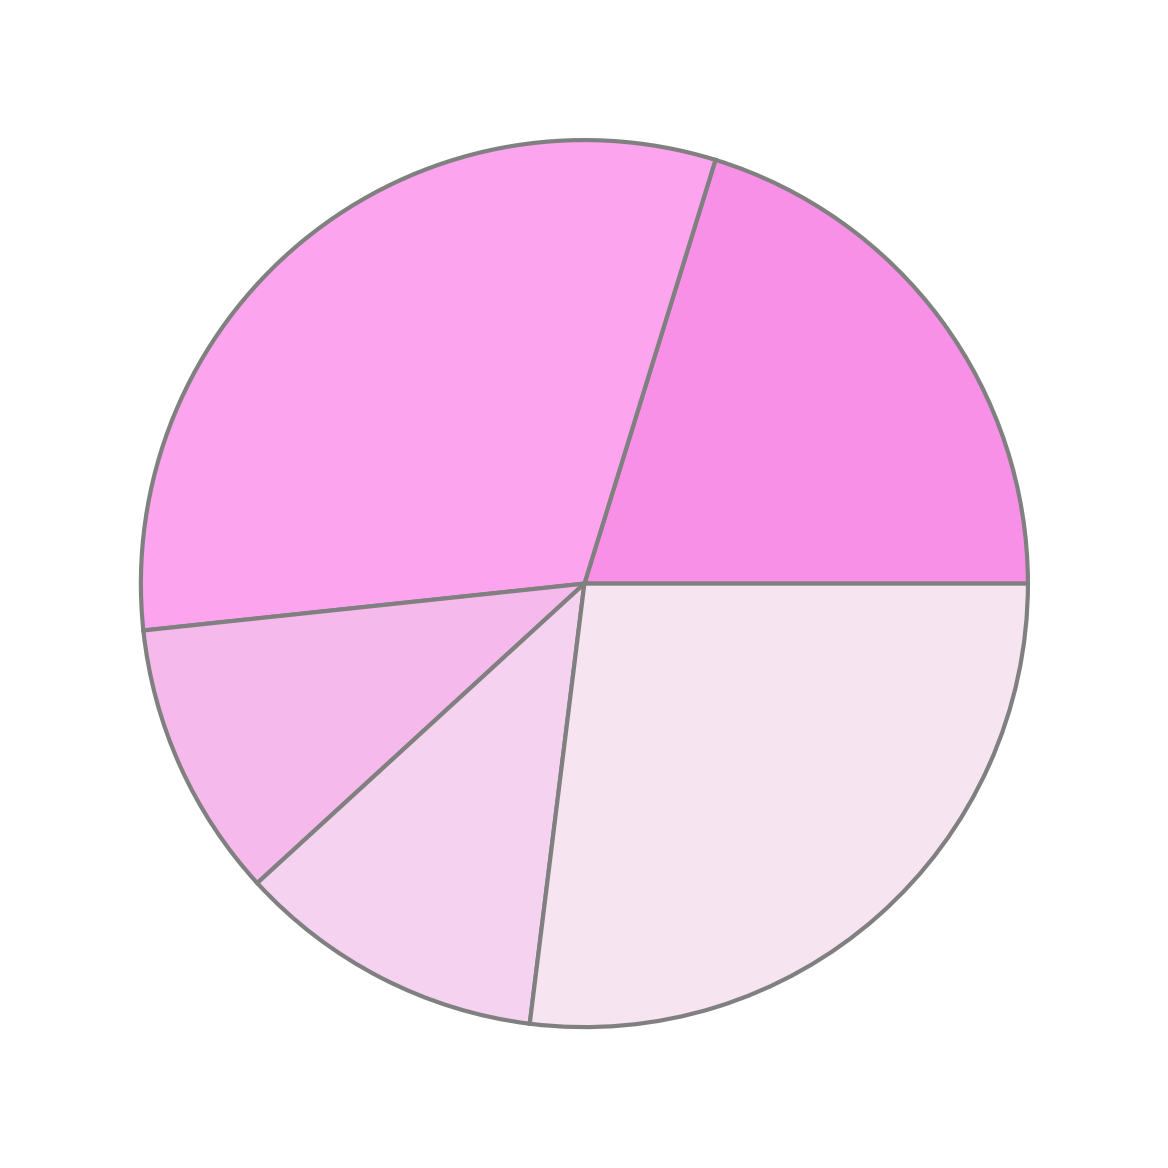

In [ ]:
# Make a pie chart of NHC’s LBs
all_NHC_type = [[],[],[],[], []]
for row in db.select(category="LB"):
    if int(row.key.split("_")[1]) in NHC_LB:
        if Chem.MolFromSmiles(row.smiles).HasSubstructMatch(Chem.MolFromSmarts("C1CN[C]N1")):
            all_NHC_type[0].append(row.smiles)
        elif Chem.MolFromSmiles(row.smiles).HasSubstructMatch(Chem.MolFromSmarts("C1=CN[C]N1")):
            all_NHC_type[1].append(row.smiles)
        elif Chem.MolFromSmiles(row.smiles).HasSubstructMatch(Chem.MolFromSmarts("c1cN[C]N1")):
            all_NHC_type[1].append(row.smiles)
        elif Chem.MolFromSmiles(row.smiles).HasSubstructMatch(Chem.MolFromSmarts("[C,c]1~[N,n]N[C]N1")):
            all_NHC_type[2].append(row.smiles)
        elif Chem.MolFromSmiles(row.smiles).HasSubstructMatch(Chem.MolFromSmarts("[C,c]1[C,c,N,n][C,c]N[C]N1")):
            all_NHC_type[3].append(row.smiles)
        else:
            all_NHC_type[4].append(row.smiles)
colors = ["#f990e7", "#fca4ed", "#f6b9ec", "#f5d2ef", "#f6e4f0"]
NHC_nums = [len(each) for each in all_NHC_type]
print(NHC_nums)
plt.figure(dpi=300)
plt.pie(NHC_nums, colors=colors, wedgeprops={'edgecolor': 'gray', 'linewidth': 1})
print("B_Radical_TypeColors")
plt.savefig("Figure/Figure1_LB_NHC_TypeColors.png", dpi=300)

In [100]:
[len(each) for each in all_NHC_type]

[18, 28, 7, 36]

In [61]:
print(len(Borane_nu_df))
Borane_nu_df_ = Borane_nu_df.loc[Borane_nu_df['deltaG_comb(kcal)'] < -4.1]
A = Borane_nu_df_['deltaG_react'].to_numpy()
B = Cl_df['deltaG_react'].to_numpy()
count = np.sum(A[:, np.newaxis] + B > -4.1)
count

20010


3581790

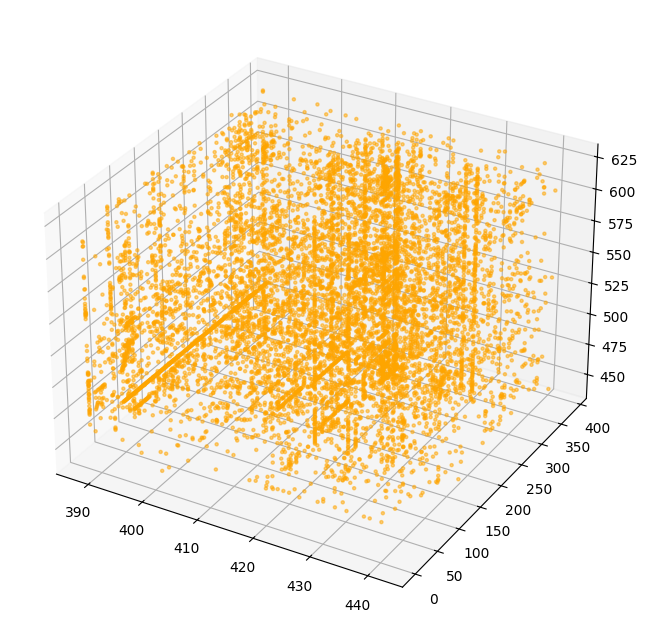

In [63]:
all_success_bs = reaction_df['B_Index'].to_numpy()
all_success_ns = reaction_df['N_Index'].to_numpy()
all_success_cls = reaction_df['Cl_Index'].to_numpy()
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(all_success_bs, all_success_ns, all_success_cls, c='orange', marker='o', s=5, alpha=0.5)
plt.savefig("Figure/Figure1_3D.png", dpi=300)

## Selection 1 The most common Borane, Nu

In [31]:
B_N_Full_df = pd.read_csv("Data/csvs/reactants_B_N_full.csv").dropna(subset=['deltaG_comb(kcal)'])
selected_BN = B_N_Full_df.loc[B_N_Full_df['deltaG_comb(kcal)'] < -4.1]
dropped_BN = B_N_Full_df.loc[B_N_Full_df['deltaG_comb(kcal)'] > -4.1]


In [32]:
B_average_Gcomb = {}
for _, row in B_N_Full_df.iterrows():
    if row.B_smiles in B_average_Gcomb.keys():
        B_average_Gcomb[row.B_smiles].append(row['deltaG_comb(kcal)'])
    else:
        B_average_Gcomb[row.B_smiles] = [row['deltaG_comb(kcal)']]
B_average_Gcomb = {key: sum(value) / len(value) for key, value in B_average_Gcomb.items()}
B_average_Gcomb = sorted(B_average_Gcomb.items(), key=lambda x: x[1])
N_average_Gcomb = {}
for _, row in B_N_Full_df.iterrows():
    if row.N_smiles in N_average_Gcomb.keys():
        N_average_Gcomb[row.N_smiles].append(row['deltaG_comb(kcal)'])
    else:
        N_average_Gcomb[row.N_smiles] = [row['deltaG_comb(kcal)']]
N_average_Gcomb = {key: sum(value) / len(value) for key, value in N_average_Gcomb.items()}
N_average_Gcomb = sorted(N_average_Gcomb.items(), key=lambda x: x[1])

In [33]:
B_select_num = {}
for _, row in selected_BN.iterrows():
    if row.B_smiles in B_select_num.keys():
        B_select_num[row.B_smiles] += 1
    else:
        B_select_num[row.B_smiles] = 1
B_dropped_num = {}
for _, row in dropped_BN.iterrows():
    if row.B_smiles in B_dropped_num.keys():
        B_dropped_num[row.B_smiles] += 1
    else:
        B_dropped_num[row.B_smiles] = 1
B_select_num = sorted(B_select_num.items(), key=lambda x: x[1], reverse=True)
B_dropped_num = sorted(B_dropped_num.items(), key=lambda x: x[1], reverse=True)

In [34]:
N_select_num = {}
for _, row in selected_BN.iterrows():
    if row.N_smiles in N_select_num.keys():
        N_select_num[row.N_smiles] += 1
    else:
        N_select_num[row.N_smiles] = 1
N_dropped_num = {}
for _, row in dropped_BN.iterrows():
    if row.N_smiles in N_dropped_num.keys():
        N_dropped_num[row.N_smiles] += 1
    else:
        N_dropped_num[row.N_smiles] = 1
N_select_num = sorted(N_select_num.items(), key=lambda x: x[1], reverse=True)
N_dropped_num = sorted(N_dropped_num.items(), key=lambda x: x[1], reverse=True)

In [35]:
N_dropped_num[:5], B_dropped_num[:5]

([('c1ccc(N(c2ccccc2)c2ccccc2)cc1', 30),
  ('N#CN1CCOCC1', 29),
  ('CN(C)C(F)(F)F', 27),
  ('Cc1c[nH]c(N)n1', 27),
  ('N#CN1CCCCC1', 26)],
 [('CN1BN(C)CC1', 97),
  ('B1OCCO1', 77),
  ('BN(C)C', 65),
  ('CBOC', 62),
  ('B1CCCO1', 48)])

In [39]:
csv_1 = pd.read_csv(r'Data\csvs\reactants_B_N.csv')
csv_2 = pd.read_csv(r"Data\csvs\reactants_Cl.csv")
for Cl_BDE in np.sort(csv_2['BDE_G'].to_numpy())[::-1][:5]:
    print(len(csv_1.loc[csv_1['BDE_G'] < Cl_BDE]))
for B_BDE in np.sort(csv_1['BDE_G'].to_numpy())[:5]:
    print(len(csv_2.loc[csv_2['BDE_G'] > B_BDE]))

19730
18981
12218
11936
10354
179
179
179
179
179


# Figure 4

## Relation deltaG and deltaGa

coef: [ 0.45954884 30.2574423 ]
Pearson r: 0.725
R^2: 0.525


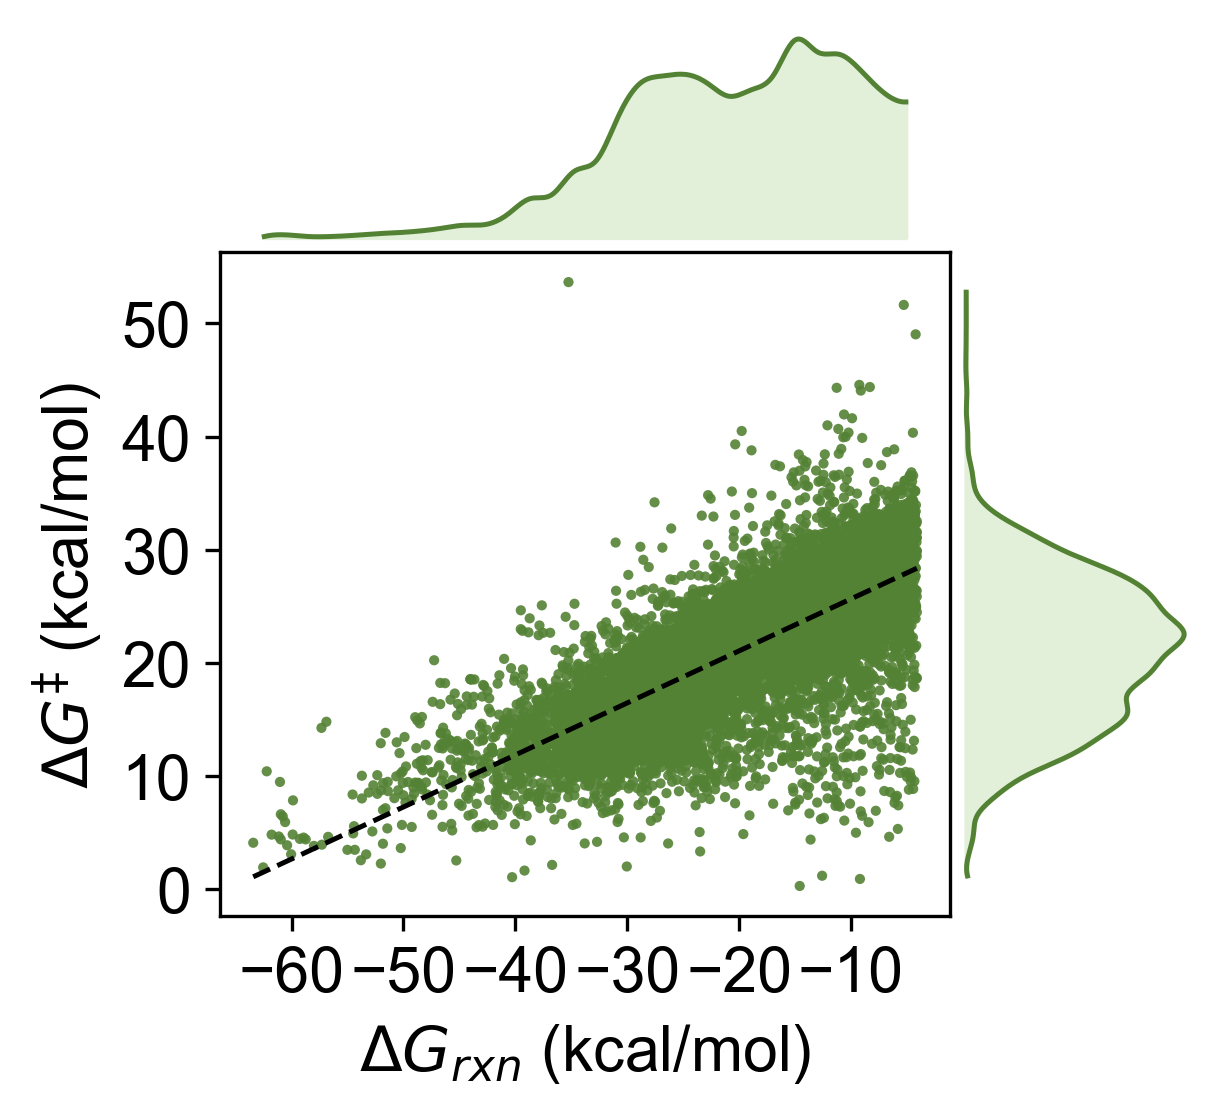

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# ===== Data =====
x = reaction_df['deltaG(kcal/mol)'].to_numpy()
y = reaction_df['deltaGa(kcal/mol)'].to_numpy()

# ===== Style =====
plt.rcParams['font.sans-serif'] = 'Arial'

color_main = (84/255,130/255,53/255)
color_fill = (226/255,240/255,217/255)

# ===== Layout =====
fig = plt.figure(figsize=(5,4), dpi=300)
gs = fig.add_gridspec(5,5)

ax_main = fig.add_subplot(gs[1:4,0:3])
ax_top = fig.add_subplot(gs[0,0:3], sharex=ax_main)
ax_right = fig.add_subplot(gs[1:4,3], sharey=ax_main)

# ===== Scatter + fit =====
plot_scatter_fit(ax_main, x, y, color=color_main)

# ===== Labels =====
ax_main.set_xlabel(r'$\Delta G_{rxn}$ (kcal/mol)', fontsize=15)
ax_main.set_ylabel(r'$\Delta G^{\ddagger}$ (kcal/mol)', fontsize=15)

ax_main.set_xticks(np.arange(-60,0,10))
ax_main.set_yticks(np.arange(0,60,10))
ax_main.tick_params(labelsize=15)

# ===== Distribution =====
plot_distribution(ax_top, x, 'top', color_line=color_main, color_fill=color_fill)
plot_distribution(ax_right, y, 'right', color_line=color_main, color_fill=color_fill)

# ===== Layout =====
plt.tight_layout()
plt.subplots_adjust(hspace=0.02, wspace=0.02)

plt.savefig("Figure/Figure4_reaction_landscape.png", dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# Statistical perspective
all_angles = []
for row_id, row in tqdm(reaction_df.iterrows()):
    B = row['B_Index']
    N = row['N_Index']
    Cl = row['Cl_Index']
    AAM = row['AAM'].split(">>")[0]
    for dbrow in db.select(B_id = B, LB_id = N, Cl_id = Cl):
        position = dbrow.positions
    mol = Chem.MolFromSmiles(AAM)
    B_atom = [atom for atom in mol.GetAtoms() if atom.GetSymbol() == 'B'][0]
    Cl_atoms = [atom for atom in mol.GetAtoms() if atom.GetSymbol() == 'Cl']
    Cl_atoms = sorted(Cl_atoms, key=lambda x: x.GetAtomMapNum())
    C_atom = [atom for atom in mol.GetAtomWithIdx(Cl_atoms[0].GetIdx()).GetNeighbors() if atom.GetSymbol() == 'C'][0]
    angle = get_bond_angle(position[B_atom.GetAtomMapNum() - 1], position[Cl_atoms[0].GetAtomMapNum() - 1], position[C_atom.GetAtomMapNum() - 1])
    all_angles.append(angle)

2010it [03:14, 10.36it/s]


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
from scipy.interpolate import make_interp_spline

# ===== Data =====
y = reaction_df['deltaGa(kcal/mol)'].to_numpy()
x1 = reaction_df['B_Cl'].to_numpy()
x2 = reaction_df['C_Cl'].to_numpy()
x3 = np.array(all_angles)

# ===== Style =====
plt.rcParams['font.sans-serif'] = 'Arial'
color_main = (84/255, 130/255, 53/255)
color_fill = (226/255, 240/255, 217/255)

# ===== Smooth histogram =====
def smooth_hist(data, bins=30):
    hist, edges = np.histogram(data, bins=bins)
    hist = hist / len(data)
    centers = 0.5 * (edges[:-1] + edges[1:])
    spline = make_interp_spline(centers, hist, k=3)
    x_smooth = np.linspace(centers.min(), centers.max(), 300)
    y_smooth = spline(x_smooth)
    return x_smooth, y_smooth

fig = plt.figure(figsize=(9,3.7), dpi=300)
gs = fig.add_gridspec(2,3, height_ratios=[1,4])

axes_top = [fig.add_subplot(gs[0,i]) for i in range(3)]
axes_main = [fig.add_subplot(gs[1,i], sharex=axes_top[i]) for i in range(3)]

plot_panel(axes_main[0], axes_top[0], x1, y,
           'B–Cl Distance (Å)', np.arange(2.0,4,0.5),
           ylabel=r'$\Delta G^{\ddagger}$ (kcal/mol)',
           color_main="#215f9a", color_fill="#4e95d9")

plot_panel(axes_main[1], axes_top[1], x2, y,
           'C–Cl Distance (Å)', np.arange(1.8,2.8,0.2),
           color_main="#13501b", color_fill="#e2f0d9")

plot_panel(axes_main[2], axes_top[2], x3, y,
           'B–Cl–C angle (°)', np.arange(100,181,20),
           color_main="#c04f15", color_fill="#f5bd9f")

plt.tight_layout()
plt.subplots_adjust(hspace=0.05, wspace=0.25)

plt.savefig("Figure/Figure4_TS_geometry.png", dpi=300, bbox_inches='tight')
plt.show()

## The influence of physical and chemical properties on the statistical part

In [ ]:
all_P_type = [[], [], [], []]
for row in db.select(category="complex_r"):
    symbol_list = 

==== BDE of C–Cl (kcal/mol) ====
coef: [ 0.03703306 18.74412643]
Pearson r: 0.055
R^2: 0.003



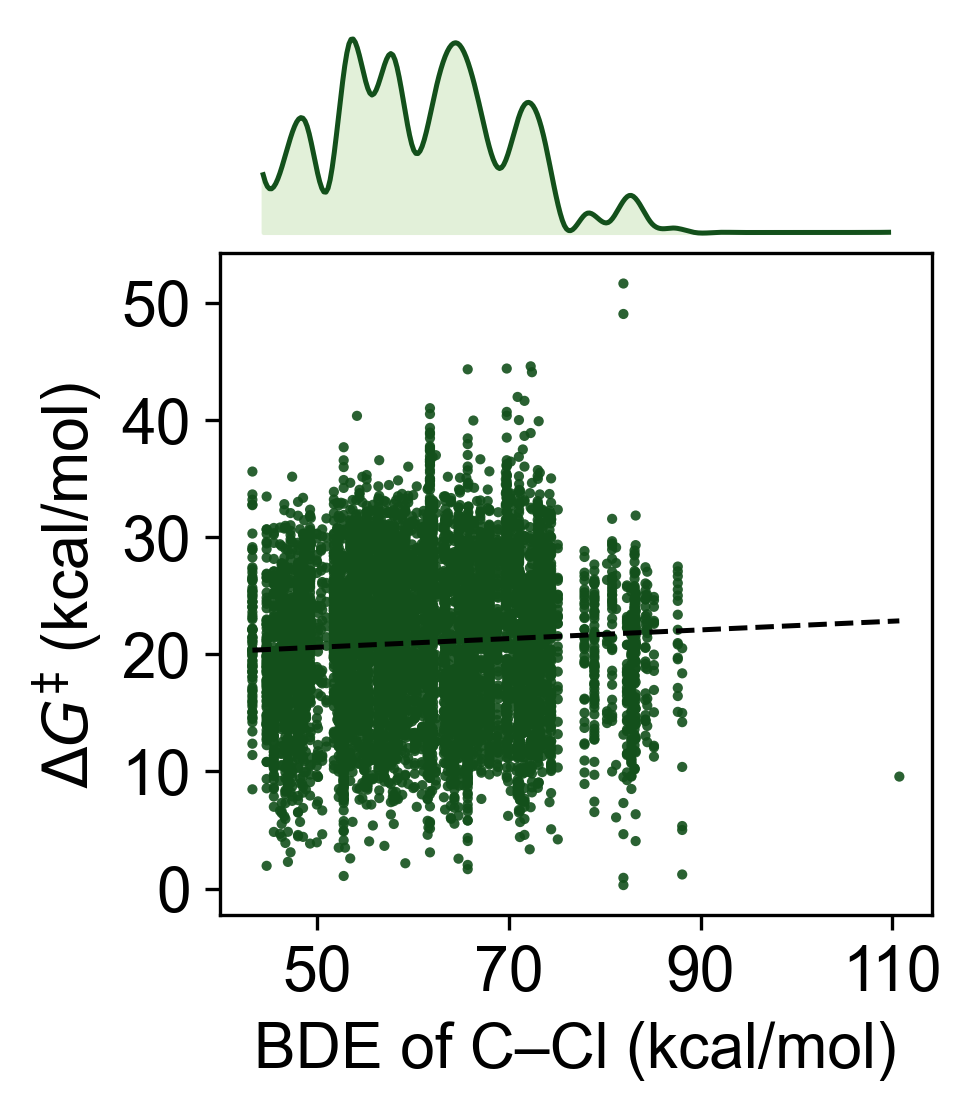

In [258]:
Cl_df = pd.read_csv("data/csvs/reactants_Cl.csv")
BDE_dict = {row['Index']: row['BDE_G'] for _, row in Cl_df.iterrows()}
x1 = np.array([BDE_dict[row['Cl_Index']] for _, row in reaction_df.iterrows()])
y = reaction_df['deltaG(kcal/mol)'].to_numpy()


fig = plt.figure(figsize=(5, 4), dpi=300)
gs = fig.add_gridspec(5, 5)
ax_main = fig.add_subplot(gs[1:4, 0:3])
ax_top = fig.add_subplot(gs[0, 0:3], sharex=ax_main)

# ===== Plot panels =====
plot_panel(ax_main, ax_top, x1, reaction_df['deltaGa(kcal/mol)'].to_numpy(), 'BDE of C–Cl (kcal/mol)', np.arange(50, 150, 20), ylabel=r'$\Delta G^{\ddagger}$ (kcal/mol)', color_main="#13501b", color_fill="#e2f0d9")
# plot_panel(ax_main, ax_top, x1, reaction_df['deltaG(kcal/mol)'].to_numpy(), 'BDE of C–Cl (kcal/mol)', np.arange(50, 150, 20), ylabel=r'$\Delta G_{rxn}$ (kcal/mol)', color_main="#215f9a", color_fill="#4e95d9", yticks=np.arange(-60, 10, 10))
plt.tight_layout()
plt.subplots_adjust(hspace=0.05, wspace=0.25)
 
# ===== Save =====
# plt.savefig("Figure/Figure4_TS_geometry.png", dpi=300, bbox_inches='tight')
plt.show()

In [179]:
import pickle
with open("Data/descriptor/BNdes_.pkl", 'rb') as f:
    B_N_des_map = pickle.load(f)
with open("Data/descriptor/Cldes_.pkl", 'rb') as f:
    Cl_des_map = pickle.load(f)

In [196]:
Cl_des_map['Cl_00488'][23]

9.94318181818182

==== C–Cl Distance (Å) ====
coef: [-24.43896162  65.5404494 ]
Pearson r: -0.200
R^2: 0.040



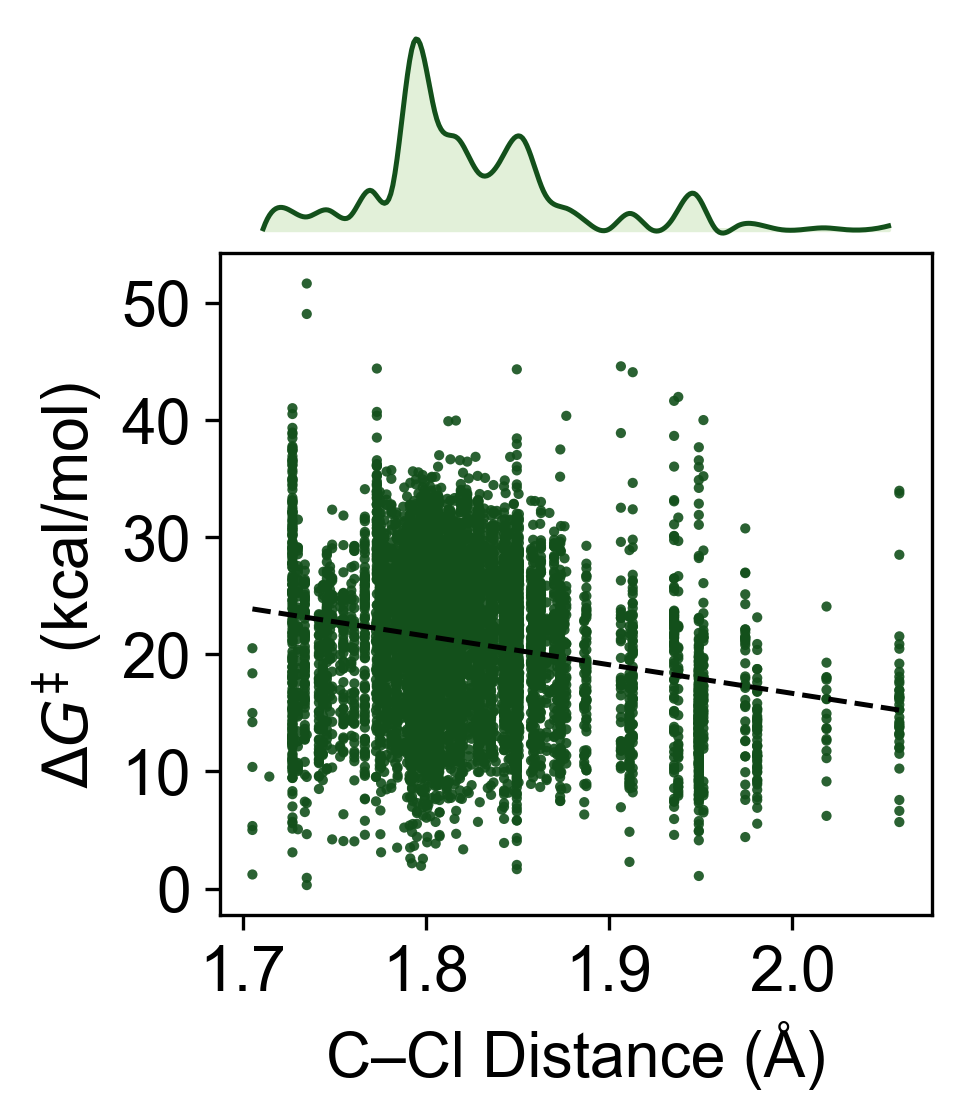

In [259]:
# C–Cl Distance (Å)
BDE_dict = {row['Index']: Cl_des_map[f'Cl_{row['Index']:05}'][17] for _, row in Cl_df.iterrows()}
x1 = np.array([BDE_dict[row['Cl_Index']] for _, row in reaction_df.iterrows()])
y = reaction_df['deltaG(kcal/mol)'].to_numpy()

fig = plt.figure(figsize=(5, 4), dpi=300)
gs = fig.add_gridspec(5, 5)
ax_main = fig.add_subplot(gs[1:4, 0:3])
ax_top = fig.add_subplot(gs[0, 0:3], sharex=ax_main)

# ===== Plot panels =====
plot_panel(ax_main, ax_top, x1, reaction_df['deltaGa(kcal/mol)'].to_numpy(), 'C–Cl Distance (Å)', np.arange(0, 2.5, 0.1), ylabel=r'$\Delta G^{\ddagger}$ (kcal/mol)', color_main="#13501b", color_fill="#e2f0d9")
# plot_panel(ax_main, ax_top, x1, reaction_df['deltaG(kcal/mol)'].to_numpy(), 'BDE of C–Cl (kcal/mol)', np.arange(50, 150, 20), ylabel=r'$\Delta G_{rxn}$ (kcal/mol)', color_main="#215f9a", color_fill="#4e95d9", yticks=np.arange(-60, 10, 10))
plt.tight_layout()
plt.subplots_adjust(hspace=0.05, wspace=0.25)
 
# ===== Save =====
# plt.savefig("Figure/Figure4_TS_geometry.png", dpi=300, bbox_inches='tight')
plt.show()

In [243]:
import pickle
with open("Data/descriptor/BNdes_.pkl", 'rb') as f:
    B_N_des_map = pickle.load(f)
with open("Data/descriptor/Cldes_new.pkl", 'rb') as f:
    Cl_des_map = pickle.load(f)

==== Buried Volume (%) ====
coef: [-0.13837604 24.31567132]
Pearson r: -0.151
R^2: 0.023



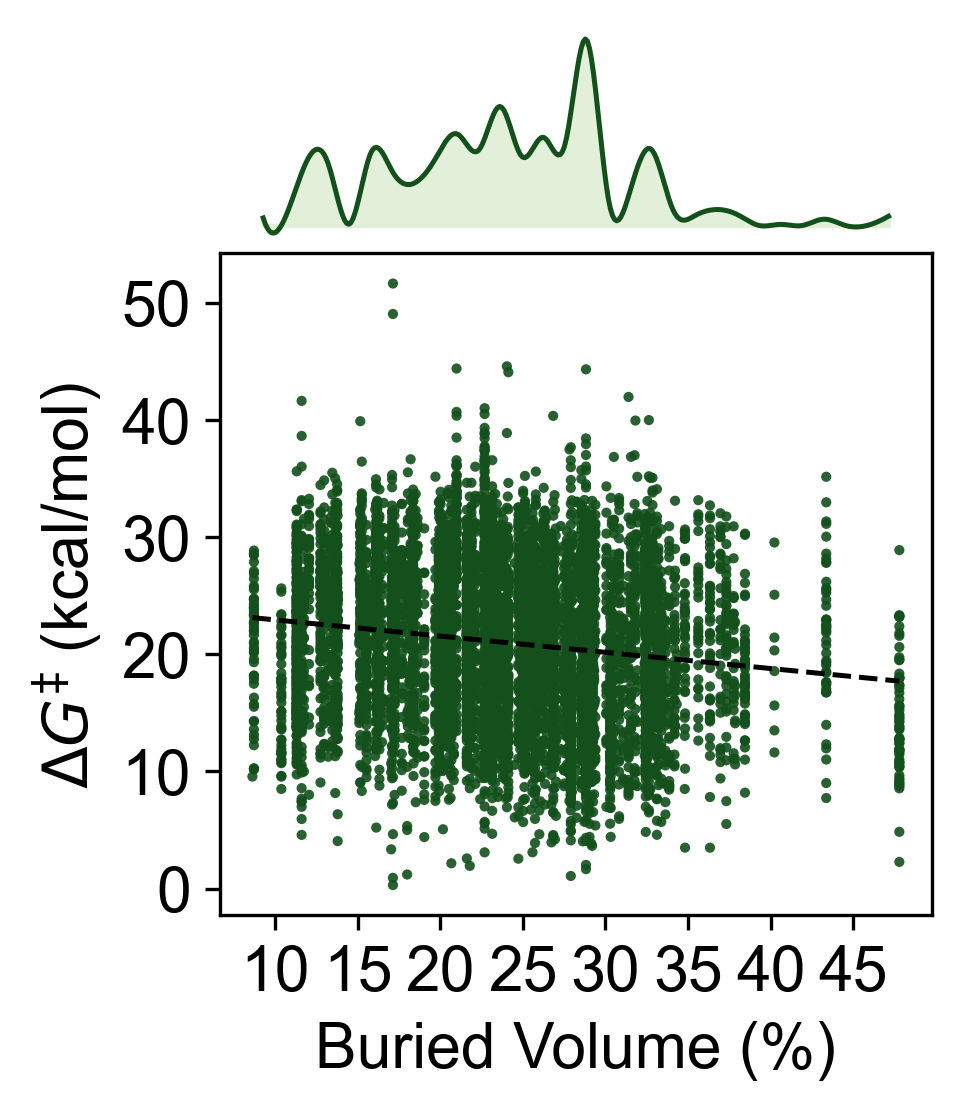

In [260]:
# BDE
BDE_dict = {row['Index']: np.sum(Cl_des_map[f'Cl_{row['Index']:05}'][24][4:]) / 4 for _, row in Cl_df.iterrows()}
x1 = np.array([BDE_dict[row['Cl_Index']] for _, row in reaction_df.iterrows()])
y = reaction_df['deltaG(kcal/mol)'].to_numpy()

fig = plt.figure(figsize=(5, 4), dpi=300)
gs = fig.add_gridspec(5, 5)
ax_main = fig.add_subplot(gs[1:4, 0:3])
ax_top = fig.add_subplot(gs[0, 0:3], sharex=ax_main)

# ===== Plot panels =====
plot_panel(ax_main, ax_top, x1, reaction_df['deltaGa(kcal/mol)'].to_numpy(), 'Buried Volume (%)', np.arange(0, 100, 5), ylabel=r'$\Delta G^{\ddagger}$ (kcal/mol)', color_main="#13501b", color_fill="#e2f0d9")
# plot_panel(ax_main, ax_top, x1, reaction_df['deltaG(kcal/mol)'].to_numpy(), 'BDE of C–Cl (kcal/mol)', np.arange(50, 150, 20), ylabel=r'$\Delta G_{rxn}$ (kcal/mol)', color_main="#215f9a", color_fill="#4e95d9", yticks=np.arange(-60, 10, 10))
plt.tight_layout()
plt.subplots_adjust(hspace=0.05, wspace=0.25)
 
# ===== Save =====
# plt.savefig("Figure/Figure4_TS_geometry.png", dpi=300, bbox_inches='tight')
plt.show()

==== Combination Energy ====
coef: [-0.10155115 16.77170026]
Pearson r: -0.267
R^2: 0.072



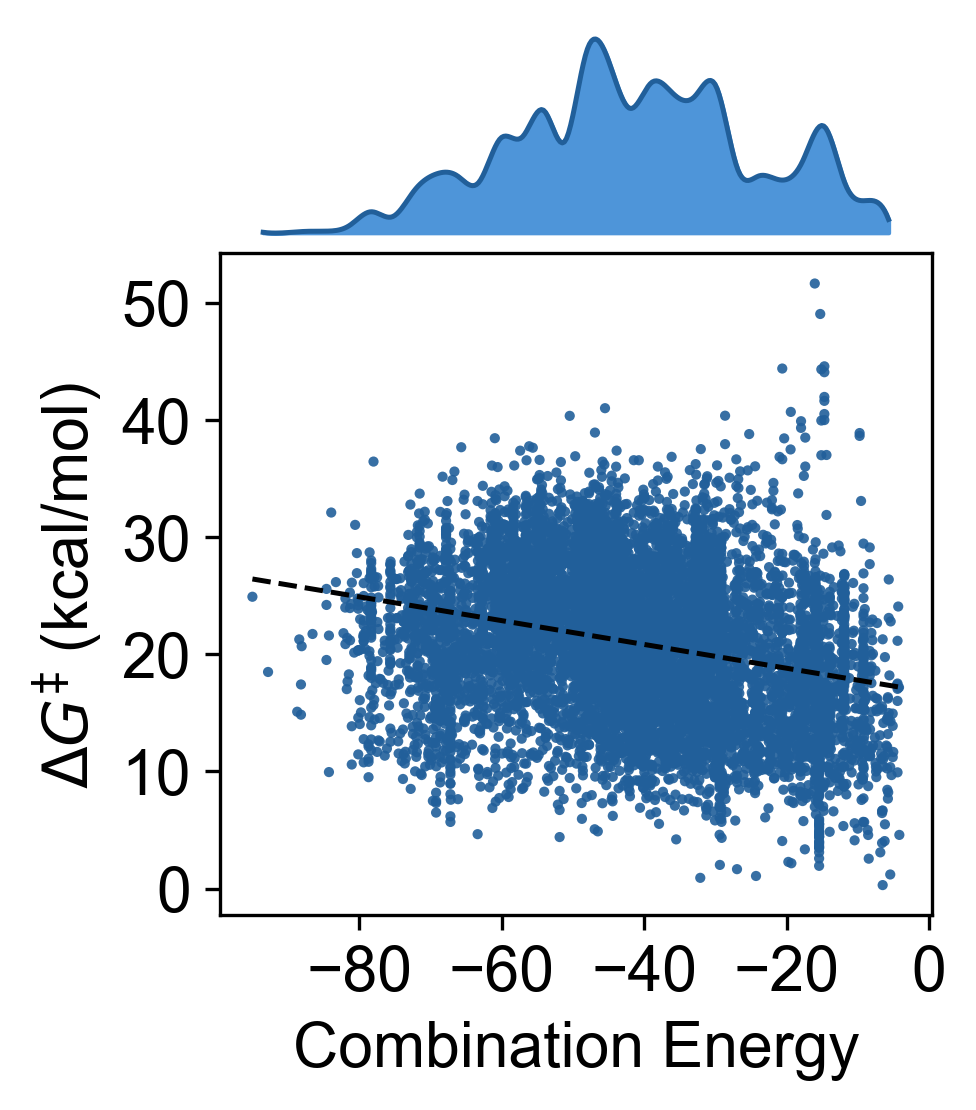

In [270]:
BN_df = pd.read_csv("data/csvs/reactants_B_N.csv")
BDE_dict = {f"B_{row['B_Index']}_N_{row['N_Index']}": row['deltaG_comb(kcal)'] for _, row in BN_df.iterrows()}
x1 = np.array([BDE_dict[f"B_{row['B_Index']}_N_{row['N_Index']}"] for _, row in reaction_df.iterrows()])
y = reaction_df['deltaG(kcal/mol)'].to_numpy()


fig = plt.figure(figsize=(5, 4), dpi=300)
gs = fig.add_gridspec(5, 5)
ax_main = fig.add_subplot(gs[1:4, 0:3])
ax_top = fig.add_subplot(gs[0, 0:3], sharex=ax_main)

# ===== Plot panels =====
plot_panel(ax_main, ax_top, x1, reaction_df['deltaGa(kcal/mol)'].to_numpy(), 'Combination Energy', np.arange(-100, 1, 20), ylabel=r'$\Delta G^{\ddagger}$ (kcal/mol)', color_main="#215f9a", color_fill="#4e95d9")
plt.tight_layout()
plt.subplots_adjust(hspace=0.05, wspace=0.25)
 
# ===== Save =====
# plt.savefig("Figure/Figure4_TS_geometry.png", dpi=300, bbox_inches='tight')
plt.show()

==== LB–B Distance (Å) ====
coef: [-14.05896982  42.99484655]
Pearson r: -0.364
R^2: 0.132



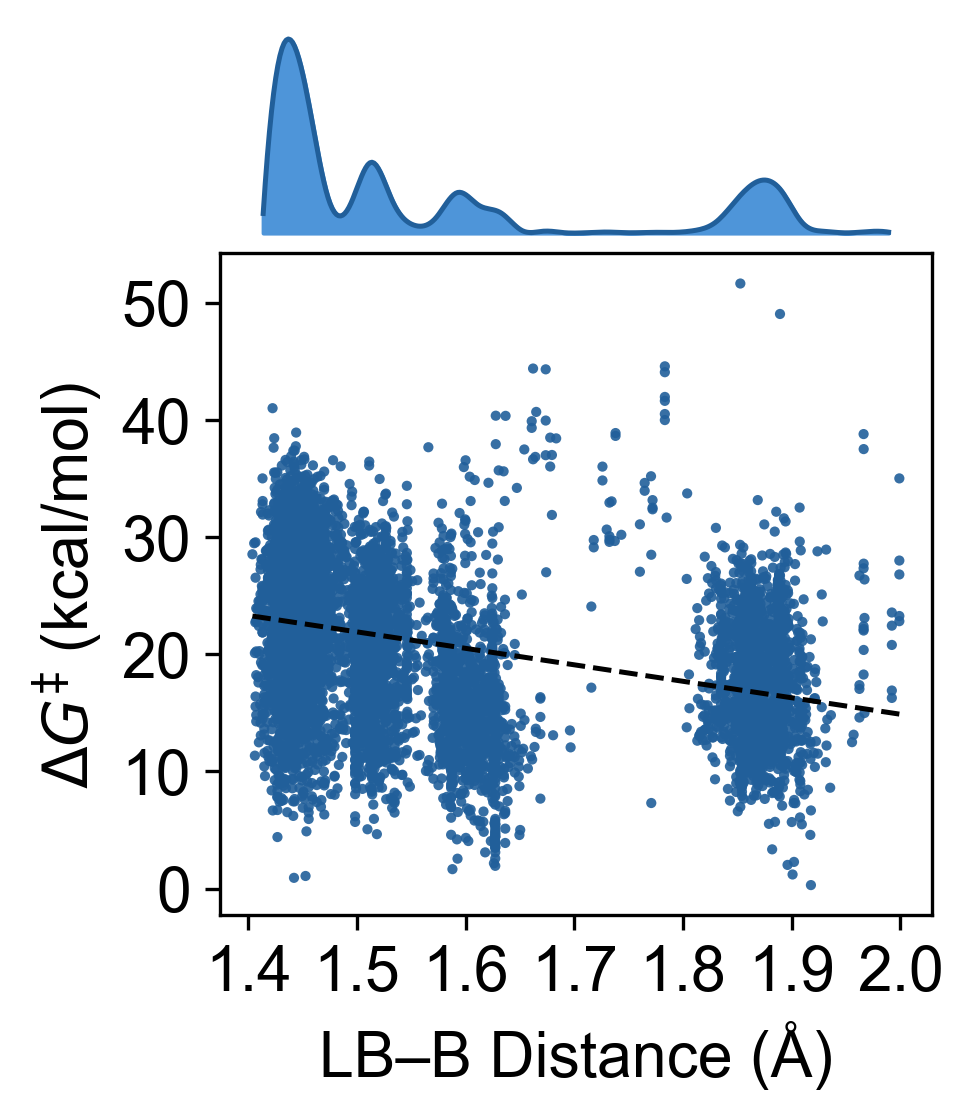

In [275]:
BDE_dict = {f"B_{row['B_Index']}_N_{row['N_Index']}": B_N_des_map[f"B_{row['B_Index']:05}_Nu_{row['N_Index']:05}"][8] for _, row in BN_df.iterrows()}
x1 = np.array([BDE_dict[f"B_{row['B_Index']}_N_{row['N_Index']}"] for _, row in reaction_df.iterrows()])
y = reaction_df['deltaG(kcal/mol)'].to_numpy()


fig = plt.figure(figsize=(5, 4), dpi=300)
gs = fig.add_gridspec(5, 5)
ax_main = fig.add_subplot(gs[1:4, 0:3])
ax_top = fig.add_subplot(gs[0, 0:3], sharex=ax_main)

# ===== Plot panels =====
plot_panel(ax_main, ax_top, x1, reaction_df['deltaGa(kcal/mol)'].to_numpy(), 'LB–B Distance (Å)', np.arange(0, 2.5, 0.1), ylabel=r'$\Delta G^{\ddagger}$ (kcal/mol)', color_main="#215f9a", color_fill="#4e95d9")
plt.tight_layout()
plt.subplots_adjust(hspace=0.05, wspace=0.25)
 
# ===== Save =====
# plt.savefig("Figure/Figure4_TS_geometry.png", dpi=300, bbox_inches='tight')
plt.show()

==== SOMO Energy (eV) ====
coef: [-1.79154914  9.5667275 ]
Pearson r: -0.249
R^2: 0.062



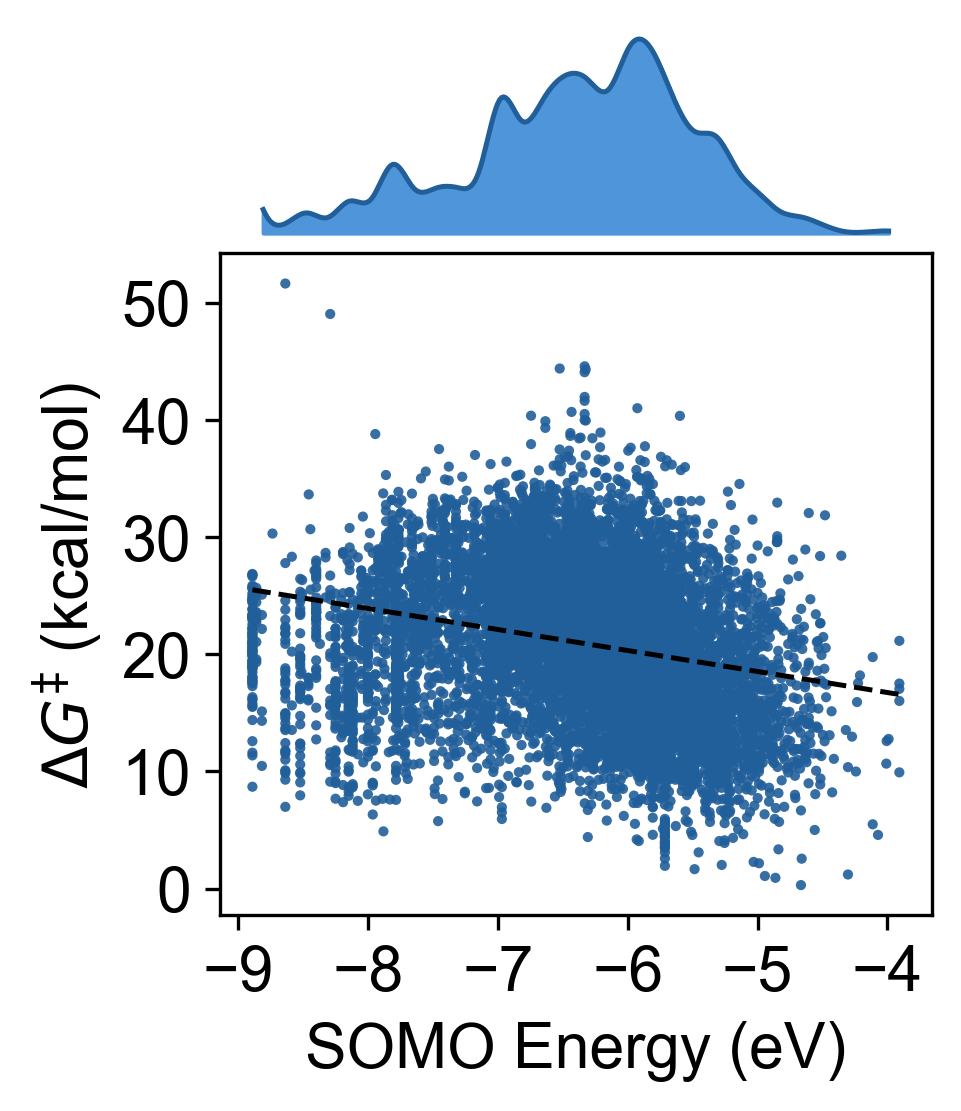

In [280]:
BDE_dict = {f"B_{row['B_Index']}_N_{row['N_Index']}": B_N_des_map[f"B_{row['B_Index']:05}_Nu_{row['N_Index']:05}"][10] * 0.04336 for _, row in BN_df.iterrows()}
x1 = np.array([BDE_dict[f"B_{row['B_Index']}_N_{row['N_Index']}"] for _, row in reaction_df.iterrows()])
y = reaction_df['deltaG(kcal/mol)'].to_numpy()


fig = plt.figure(figsize=(5, 4), dpi=300)
gs = fig.add_gridspec(5, 5)
ax_main = fig.add_subplot(gs[1:4, 0:3])
ax_top = fig.add_subplot(gs[0, 0:3], sharex=ax_main)

# ===== Plot panels =====
plot_panel(ax_main, ax_top, x1, reaction_df['deltaGa(kcal/mol)'].to_numpy(), 'SOMO Energy (eV)', np.arange(-10, 0, 1), ylabel=r'$\Delta G^{\ddagger}$ (kcal/mol)', color_main="#215f9a", color_fill="#4e95d9")
plt.tight_layout()
plt.subplots_adjust(hspace=0.05, wspace=0.25)
 
# ===== Save =====
# plt.savefig("Figure/Figure4_TS_geometry.png", dpi=300, bbox_inches='tight')
plt.show()

In [300]:
import pickle
with open("Data/descriptor/BNdes_new.pkl", 'rb') as f:
    B_N_des_map = pickle.load(f)

In [303]:
B_N_des_map['B_00388_Nu_00000']

[-61.82855829,
 -460.2931031,
 0.139955,
 -0.567705,
 0.316994,
 0.423247,
 -0.0096245659,
 0.022007217,
 1.5134038689655844,
 -183.41825,
 -134.42305,
 21.818175,
 26.122825,
 -185.07485,
 -179.345775,
 -4.423875,
 26.524425,
 4.1937,
 0.748239,
 -0.825646,
 -0.58034,
 0.704475,
 -0.361471,
 -0.0230361566,
 0.1164657189,
 -0.2587401352,
 1.631803678969992,
 1.9314722718434245,
 102.22751464500074,
 -196.98479999999998,
 -172.37425,
 14.187775,
 19.872925,
 8.9694,
 0.873035,
 -0.988449,
 0.0,
 1.6011015789449463,
 0.1164657189,
 -0.1497546753,
 4.376936771122014,
 4.438861622465832,
 -0.05429442857142858,
 -0.14174742857142855,
 3.1338457366648163,
 1.5238054151728835,
 [100.0,
  99.94834710743802,
  99.17355371900827,
  99.27685950413223,
  77.01446280991735,
  85.6663223140496,
  64.6694214876033,
  61.8801652892562],
 [97.17894606169698,
  88.75302588293712,
  67.26149835516107,
  63.518713922164984,
  72.52498293091676,
  56.58245918937372,
  31.649183787474396,
  19.4463410092483

==== Buried Volume (%) ====
coef: [-0.05076168 21.63354719]
Pearson r: -0.099
R^2: 0.010



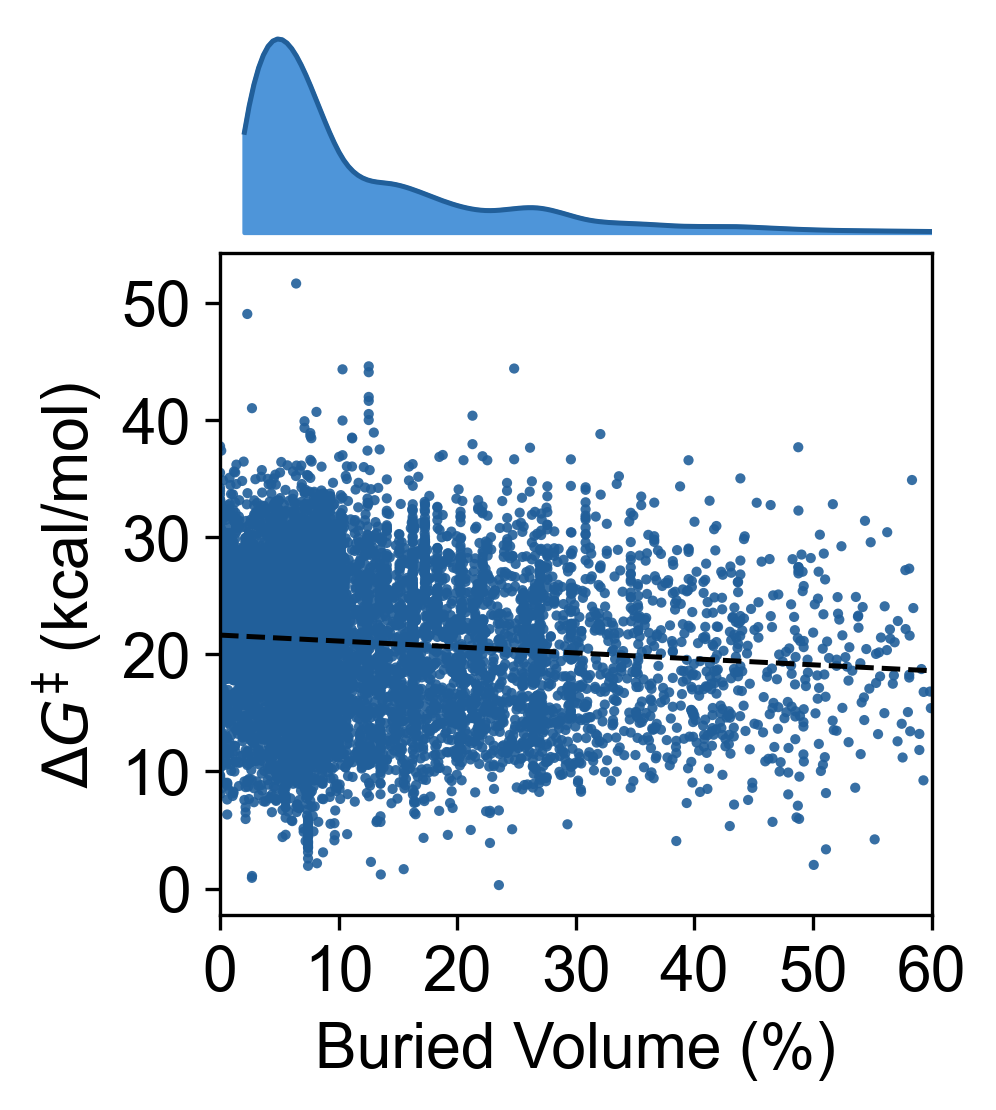

In [299]:
BDE_dict = {f"B_{row['B_Index']}_N_{row['N_Index']}": B_N_des_map[f"B_{row['B_Index']:05}_Nu_{row['N_Index']:05}"][47] for _, row in BN_df.iterrows()}
x1 = np.array([BDE_dict[f"B_{row['B_Index']}_N_{row['N_Index']}"] for _, row in reaction_df.iterrows()])
y = reaction_df['deltaG(kcal/mol)'].to_numpy()


fig = plt.figure(figsize=(5, 4), dpi=300)
gs = fig.add_gridspec(5, 5)
ax_main = fig.add_subplot(gs[1:4, 0:3])
ax_top = fig.add_subplot(gs[0, 0:3], sharex=ax_main)

# ===== Plot panels =====
plot_panel(ax_main, ax_top, x1, reaction_df['deltaGa(kcal/mol)'].to_numpy(), 'Buried Volume (%)', np.arange(0, 100, 10), ylabel=r'$\Delta G^{\ddagger}$ (kcal/mol)', color_main="#215f9a", color_fill="#4e95d9")
plt.xlim(0, 60)
plt.tight_layout()
plt.subplots_adjust(hspace=0.05, wspace=0.25)
 
# ===== Save =====
# plt.savefig("Figure/Figure4_TS_geometry.png", dpi=300, bbox_inches='tight')
plt.show()

In [287]:
from DFTStructureGenerator import logfile_process, FormatConverter
import glob
molecules = []
for log_file in glob.glob(r"D:\OneDrive_all\OneDrive\Work\文章\6_Borane_Dataset\CView\B_00388_Nu_00137_Cl_00504_00*.log"):
    log = logfile_process.Logfile(log_file)
    molecules.append({
        "name": 'a',
        "atomlist": log.symbol_list,
        "positions": log.running_positions[-1]
    })
FormatConverter.write_xyz_file(r"D:\OneDrive_all\OneDrive\Work\文章\6_Borane_Dataset\CView\B_00388_Nu_00137_Cl_00504.xyz", molecules)

In [290]:
from DFTStructureGenerator import logfile_process, FormatConverter
import glob
molecules = []
for log_file in glob.glob(r"D:\OneDrive_all\OneDrive\Work\文章\6_Borane_Dataset\CView\B_00388_Nu_00137_r_*.log"):
    log = logfile_process.Logfile(log_file)
    molecules.append({
        "name": 'a',
        "atomlist": log.symbol_list,
        "positions": log.first_atom_position
    })
FormatConverter.write_xyz_file(r"D:\OneDrive_all\OneDrive\Work\文章\6_Borane_Dataset\CView\B_00388_Nu_00137_r.xyz", molecules)

In [ ]:
set ref [atomselect top "name B Cl P" frame 0]
for {set i 1} {$i < [molinfo top get numframes]} {incr i} {
    set sel [atomselect top "name B Cl P" frame $i]
    $sel move [measure fit $sel $ref]
}

# Figure In SI

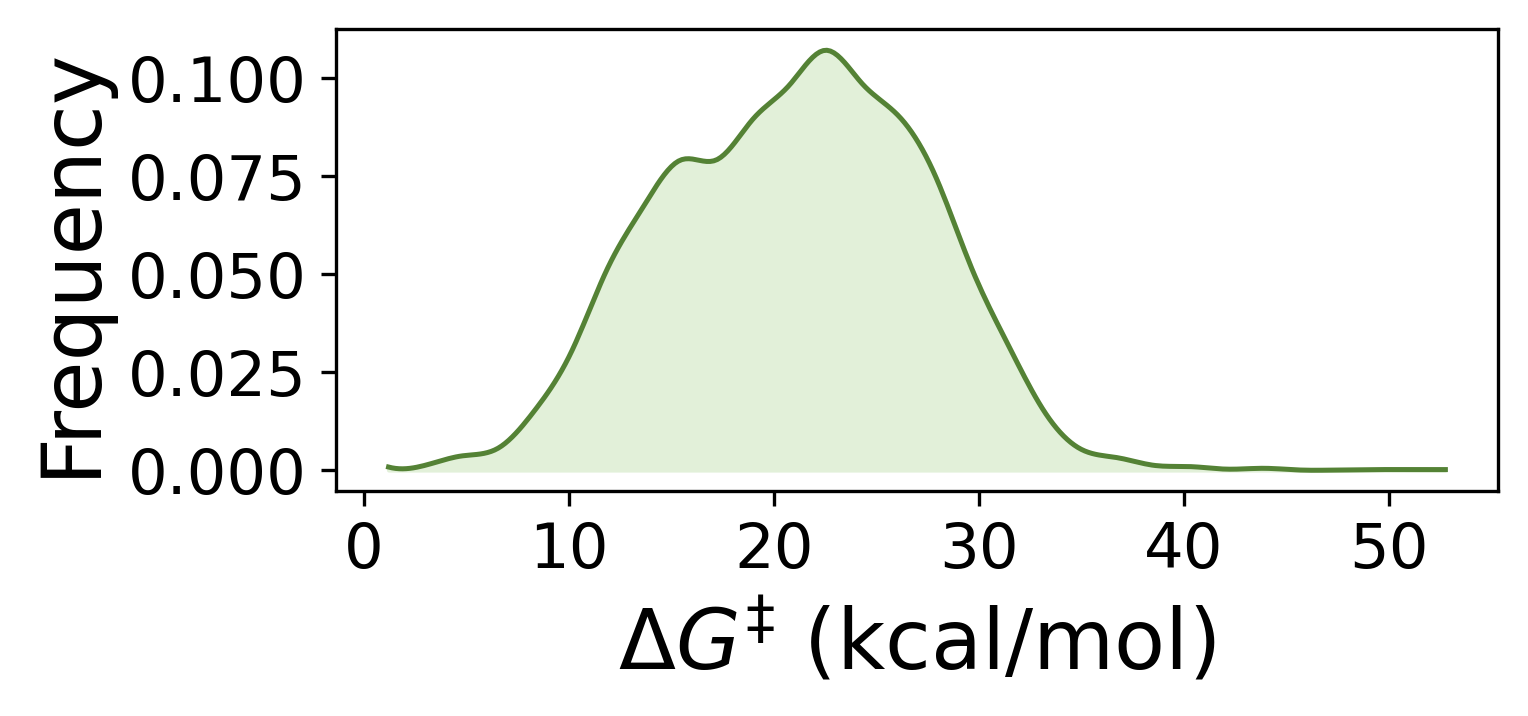

In [28]:
fig = plt.figure(figsize=(5,2), dpi=300)
ax = fig.add_subplot()
color_main = (84/255,130/255,53/255)
color_fill = (226/255,240/255,217/255)
x = pd.read_csv(r"Data\TS\Borane_all.csv")['deltaGa(kcal/mol)']
plot_distribution(ax, x, 'top', color_line=color_main, color_fill=color_fill, write_axis = True)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel("$\Delta G^{\ddagger}$ (kcal/mol)", fontsize=20)
plt.ylabel("Frequency", fontsize=20)
plt.show()

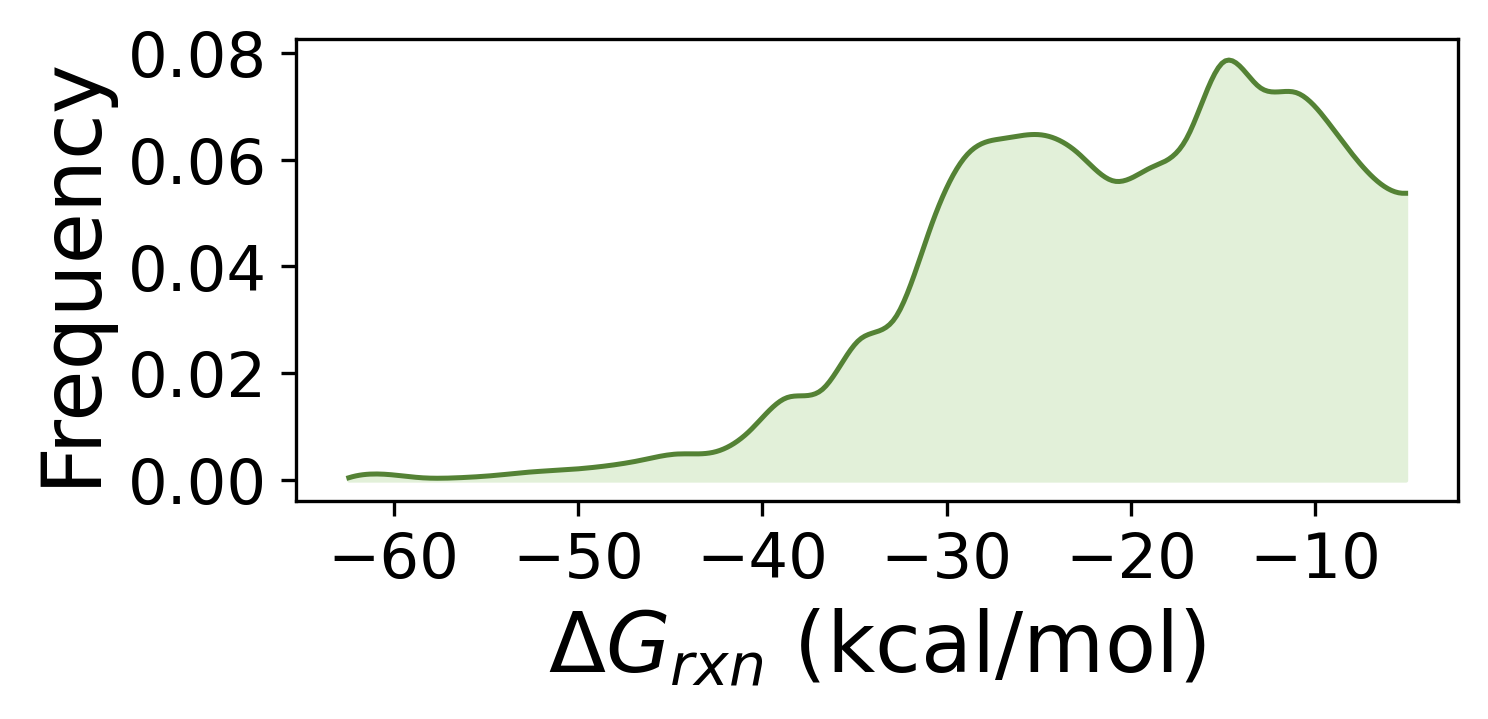

In [29]:
fig = plt.figure(figsize=(5,2), dpi=300)
ax = fig.add_subplot()
color_main = (84/255,130/255,53/255)
color_fill = (226/255,240/255,217/255)
x = pd.read_csv(r"Data\TS\Borane_all.csv")['deltaG(kcal/mol)']
plot_distribution(ax, x, 'top', color_line=color_main, color_fill=color_fill, write_axis = True)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel("$\Delta G_{rxn}$ (kcal/mol)", fontsize=20)
plt.ylabel("Frequency", fontsize=20)
plt.show()

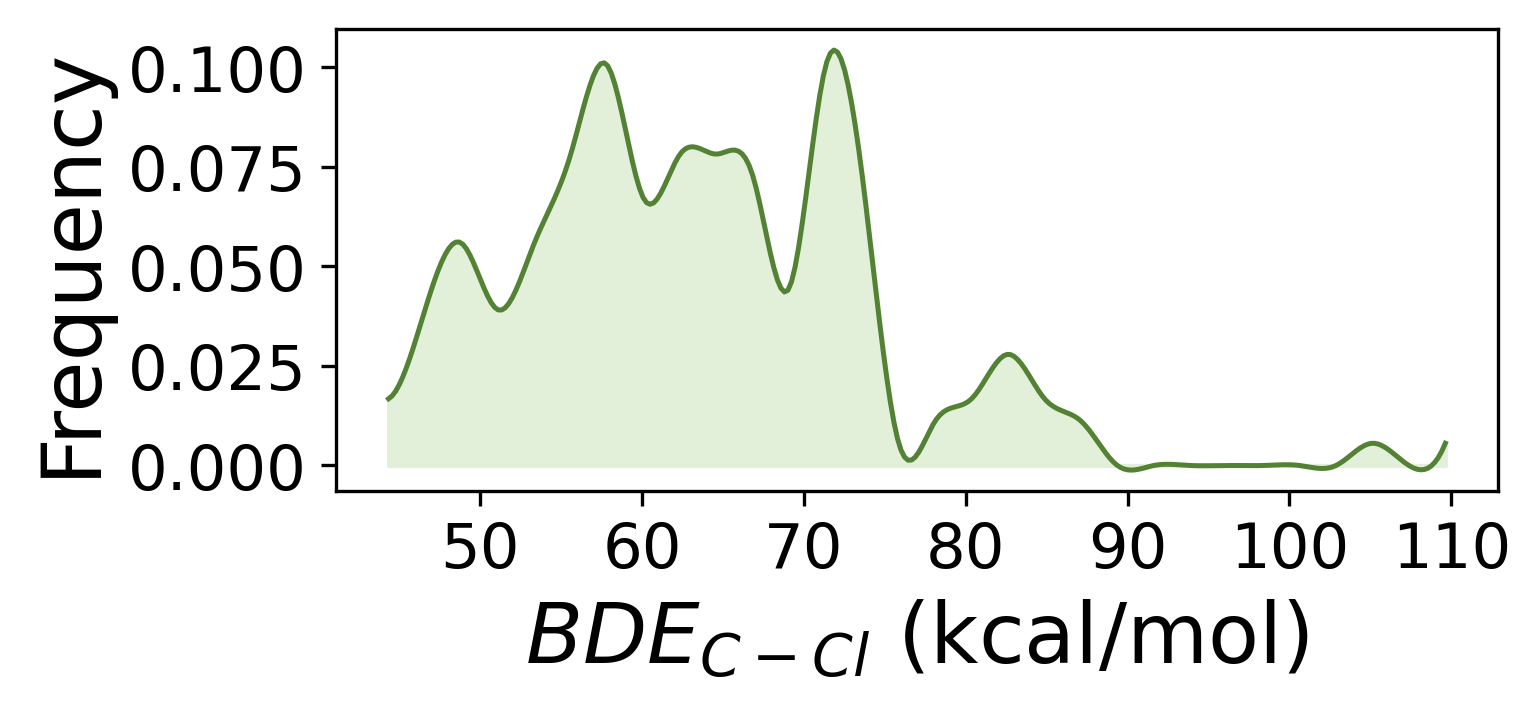

In [30]:
fig = plt.figure(figsize=(5,2), dpi=300)
ax = fig.add_subplot()
color_main = (84/255,130/255,53/255)
color_fill = (226/255,240/255,217/255)
x = pd.read_csv(r"Data\csvs\reactants_Cl.csv")['BDE_G']
plot_distribution(ax, x, 'top', color_line=color_main, color_fill=color_fill, write_axis = True)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel("$ BDE_{C-Cl}$ (kcal/mol)", fontsize=20)
plt.ylabel("Frequency", fontsize=20)
plt.show()